# **🌍 Country Segmentation for Global Development Strategy**


This project is a complete Unsupervised Machine Learning Case Study focused on discovering hidden country segments using socio-economic indicators.

The project flow should look like this:

1. Business Understanding
2. Data Loading
3. Data Inspection
4. EDA
5. Outlier Analysis
6. Feature Scaling
7. PCA
8. K-Means Clustering
9. Hierarchical Clustering
10. DBSCAN
11. Cluster Evaluation
12. Business Interpretation
13. Policy Recommendations
14. Executive Summary
  

Final project Structure

1. Title & Business Problem
2. Import Libraries
3. Load Dataset
4. Initial Inspection
5. EDA
6. Outlier Handling
7. Feature Scaling
8. PCA
9. K-Means
10. Hierarchical Clustering
11. DBSCAN
12. Model Evaluation
13. Cluster Profiling
14. Business Recommendations
15. Executive Summary
16. Final Conclusion

# **SECTION 1 — Define Problem & Load Data**


## Business Problem

Global development organizations must allocate limited development funds efficiently across countries with highly diverse socio-economic conditions. Traditional classifications such as *“developed”* and *“developing”* are often too broad and fail to capture the deeper economic, healthcare, demographic, and trade-related differences between nations.

Countries may exhibit very different development patterns, such as:

- High GDP but poor healthcare outcomes
- Strong international trade but low life expectancy
- Low income with improving social indicators
- High fertility and child mortality despite economic growth

Because of these variations, a one-size-fits-all development strategy becomes ineffective.

To address this challenge, this project applies **unsupervised machine learning techniques** to identify hidden country segments using socio-economic indicators from the `Country-data.csv` dataset.

The identified clusters will help policymakers and global development organizations:

- Allocate funds more effectively
- Prioritize high-risk and vulnerable nations
- Design cluster-specific intervention programs
- Improve long-term policy planning
- Support evidence-based global development strategies

---

## Business Context

Global economies differ significantly in terms of:

- Income levels
- Healthcare quality
- Child mortality
- Fertility rates
- Trade dependency
- Inflation
- Economic productivity

Traditional country classifications often overlook these nuanced socio-economic differences.

For example:

- A country may have high GDP but unequal healthcare access
- Another may show strong exports but poor living conditions
- Some low-income countries may still demonstrate positive development trends

Therefore, clustering techniques help uncover:

- Hidden similarities between countries
- Underlying development patterns
- Economically and socially comparable groups
- Aid prioritization segments
- Countries requiring urgent intervention

This segmentation enables organizations to move beyond generic policies and adopt more targeted and effective development strategies.

---

## Project Objective

The primary objective of this project is to segment countries into homogeneous groups using socio-economic indicators so that global development organizations can:

- Allocate development funds efficiently
- Prioritize intervention programs
- Identify vulnerable country groups
- Design cluster-specific development strategies
- Improve policy decision-making

---

## Project Objectives

The key objectives of this analysis are:

1. Perform Exploratory Data Analysis (EDA)
   - Understand feature distributions
   - Detect outliers and skewness
   - Explore relationships between indicators

2. Handle Outliers and Scale Features
   - Apply IQR-based outlier treatment
   - Standardize features using StandardScaler

3. Apply Dimensionality Reduction
   - Use Principal Component Analysis (PCA)
   - Retain maximum variance with fewer dimensions

4. Apply Multiple Clustering Techniques
   - K-Means Clustering
   - Hierarchical Clustering
   - DBSCAN Clustering

5. Compare Clustering Performance
   - Silhouette Score
   - Davies-Bouldin Index
   - Calinski-Harabasz Score

6. Interpret Country Segments
   - Profile each cluster
   - Identify representative countries
   - Analyze socio-economic characteristics

7. Provide Actionable Policy Recommendations
   - Recommend targeted development strategies
   - Suggest cluster-specific intervention plans
   - Identify future policy opportunities

---

## Expected Outcome

The final outcome of this project is a data-driven country segmentation framework that enables:

- Better global aid allocation
- Improved development planning
- Cluster-specific policy design
- Identification of high-risk nations
- Strategic socio-economic intervention programs

This approach allows global organizations to make smarter, evidence-based development decisions instead of relying on overly simplified country classifications.

## Import Libraries & Configure Environment

This section imports all required libraries for:
- data manipulation
- visualization
- preprocessing
- dimensionality reduction
- clustering
- model evaluation

In [1]:
# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')


# =============================================================================
# CONFIGURATION VARIABLES
# =============================================================================

RANDOM_STATE = 42

N_COMPONENTS = 3

K_CLUSTERS = 3

DBSCAN_EPS = 1.2

DBSCAN_MIN_SAMPLES = 5


# =============================================================================
# VISUALIZATION SETTINGS
# =============================================================================

plt.style.use('default')

sns.set_style("whitegrid")

## Load Dataset

The dataset contains socio-economic indicators for countries across:
- health
- trade
- economy
- mortality
- fertility
- development

We first load and inspect the dataset structure.

In [2]:
import pandas as pd
import gdown


# ============================================
# SECTION 2 : DOWNLOAD DATASET FROM GOOGLE DRIVE
# ============================================

file_id = "1SWUXaC78y2lnahVnUwBPmyXOicJW41Po"

url = f"https://drive.google.com/uc?id={file_id}"

output = "Country-data.csv"

gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1SWUXaC78y2lnahVnUwBPmyXOicJW41Po
To: /content/Country-data.csv
100%|██████████| 9.23k/9.23k [00:00<00:00, 17.7MB/s]


'Country-data.csv'

In [3]:
def load_data(file_path):
    """
    Load dataset from CSV file.

    Parameters
    ----------
    file_path : str
        Path to dataset file

    Returns
    -------
    df : pandas.DataFrame
        Loaded dataset
    """

    df = pd.read_csv(file_path)

    print("Dataset Loaded Successfully")
    print("Dataset Shape:", df.shape)

    return df


df = load_data("Country-data.csv")



Dataset Loaded Successfully
Dataset Shape: (167, 10)


## Initial Data Inspection

This section helps us understand:
- dataset dimensions
- feature data types
- summary statistics
- missing values
- overall structure

In [4]:
def inspect_data(df):
    """
    Perform initial dataset inspection.
    """

    print("\n================ HEAD =================")
    display(df.head())

    print("\n================ INFO =================")
    print(df.info())

    print("\n================ SUMMARY STATISTICS =================")
    display(df.describe())

    print("\n================ MISSING VALUES =================")
    display(df.isnull().sum())

    print("\n================ DATA TYPE INTERPRETATION =================")

    object_cols = df.select_dtypes(include='object').columns.tolist()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

    print("Categorical Columns:")
    print(object_cols)

    print("\nNumerical Columns:")
    print(numeric_cols)

    print("\nObservations:")
    print("- The dataset mainly consists of numerical features suitable for clustering.")
    print("- 'country' is the only categorical/object column.")
    print("- Most variables are stored as float64, enabling mathematical computations.")
    print("- No significant datatype inconsistencies are observed.")
    print("- Missing values should be handled before model training if present.")


inspect_data(df)


================ HEAD =================


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



================ INFO =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

================ SUMMARY STATISTICS =================


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000



================ MISSING VALUES =================


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



================ DATA TYPE INTERPRETATION =================

Dataset contains 167 rows and 10 columns.

Categorical Columns:
['country']

Numerical Columns:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Observations:
- The dataset mainly consists of numerical features suitable for clustering.
- 'country' is the only categorical/object column.
- Most variables are stored as float64, enabling mathematical computations.
- No significant datatype inconsistencies are observed.
- Missing values should be handled before model training if present.


## Data Types and Column Interpretation

- The dataset contains both categorical and numerical variables.
- The `country` column is of type `object`, representing country names.
- All remaining features are numerical (`float64`) and suitable for clustering algorithms.
- Numerical variables include economic, health, and demographic indicators such as income, inflation, life expectancy, and GDP per capita.
- No datatype inconsistencies were observed during inspection.
- The dataset does not contain significant missing values.

## Feature Description Table

| Feature | Description |
|---|---|
| country | Name of the country |
| child_mort | Death of children under 5 years per 1,000 live births |
| exports | Exports of goods and services as percentage of GDP |
| health | Total health spending as percentage of GDP |
| imports | Imports of goods and services as percentage of GDP |
| income | Net income per person |
| inflation | Annual inflation rate (%) |
| life_expec | Average life expectancy at birth |
| total_fer | Total fertility rate (children per woman) |
| gdpp | GDP per capita in USD |

# **SECTION 2 — Data Preprosessing and EDA**

### Exploratory Data Analysis (EDA)

EDA helps us:
- understand feature distributions
- detect skewness
- identify outliers
- analyze correlations
- discover initial patterns

## Feature Distributions

Histograms help identify:
- skewed features
- spread of values
- abnormal distributions

**Histograms**

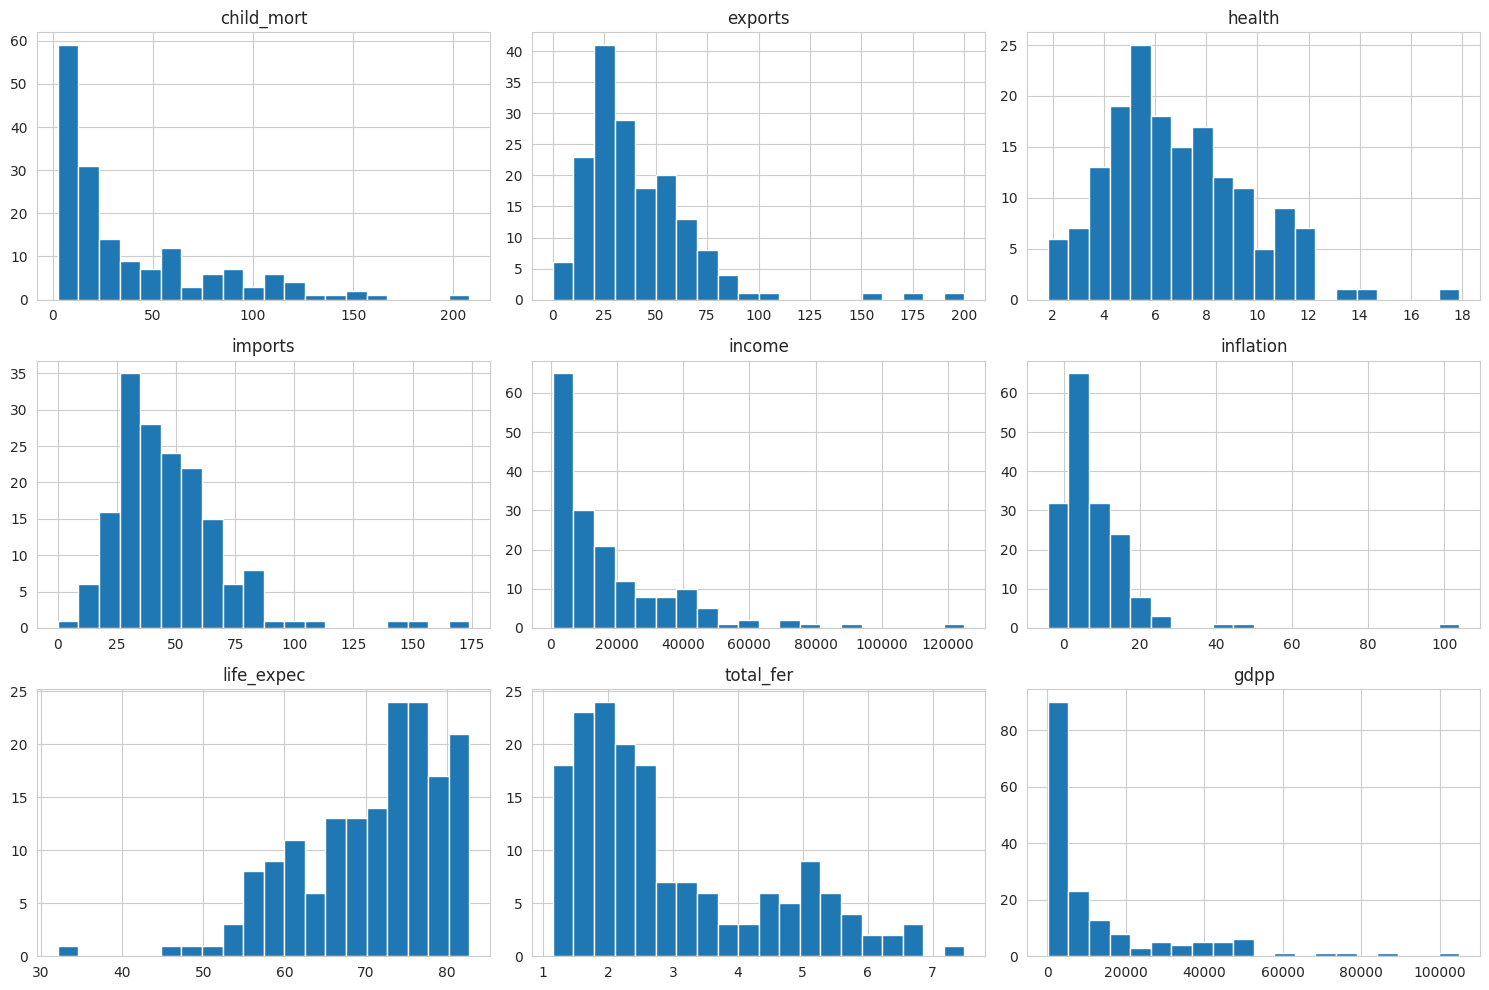

In [5]:
def plot_histograms(data):
    """
    Plot histograms for all numerical features.
    """

    data.hist(
        figsize=(15,10),
        bins=20
    )

    plt.tight_layout()
    plt.show()


numeric_data = df.drop('country', axis=1)

plot_histograms(numeric_data)

## Outlier Detection

Boxplots help identify:
- extreme countries
- spread of variables
- potential anomalies

**Boxplots**

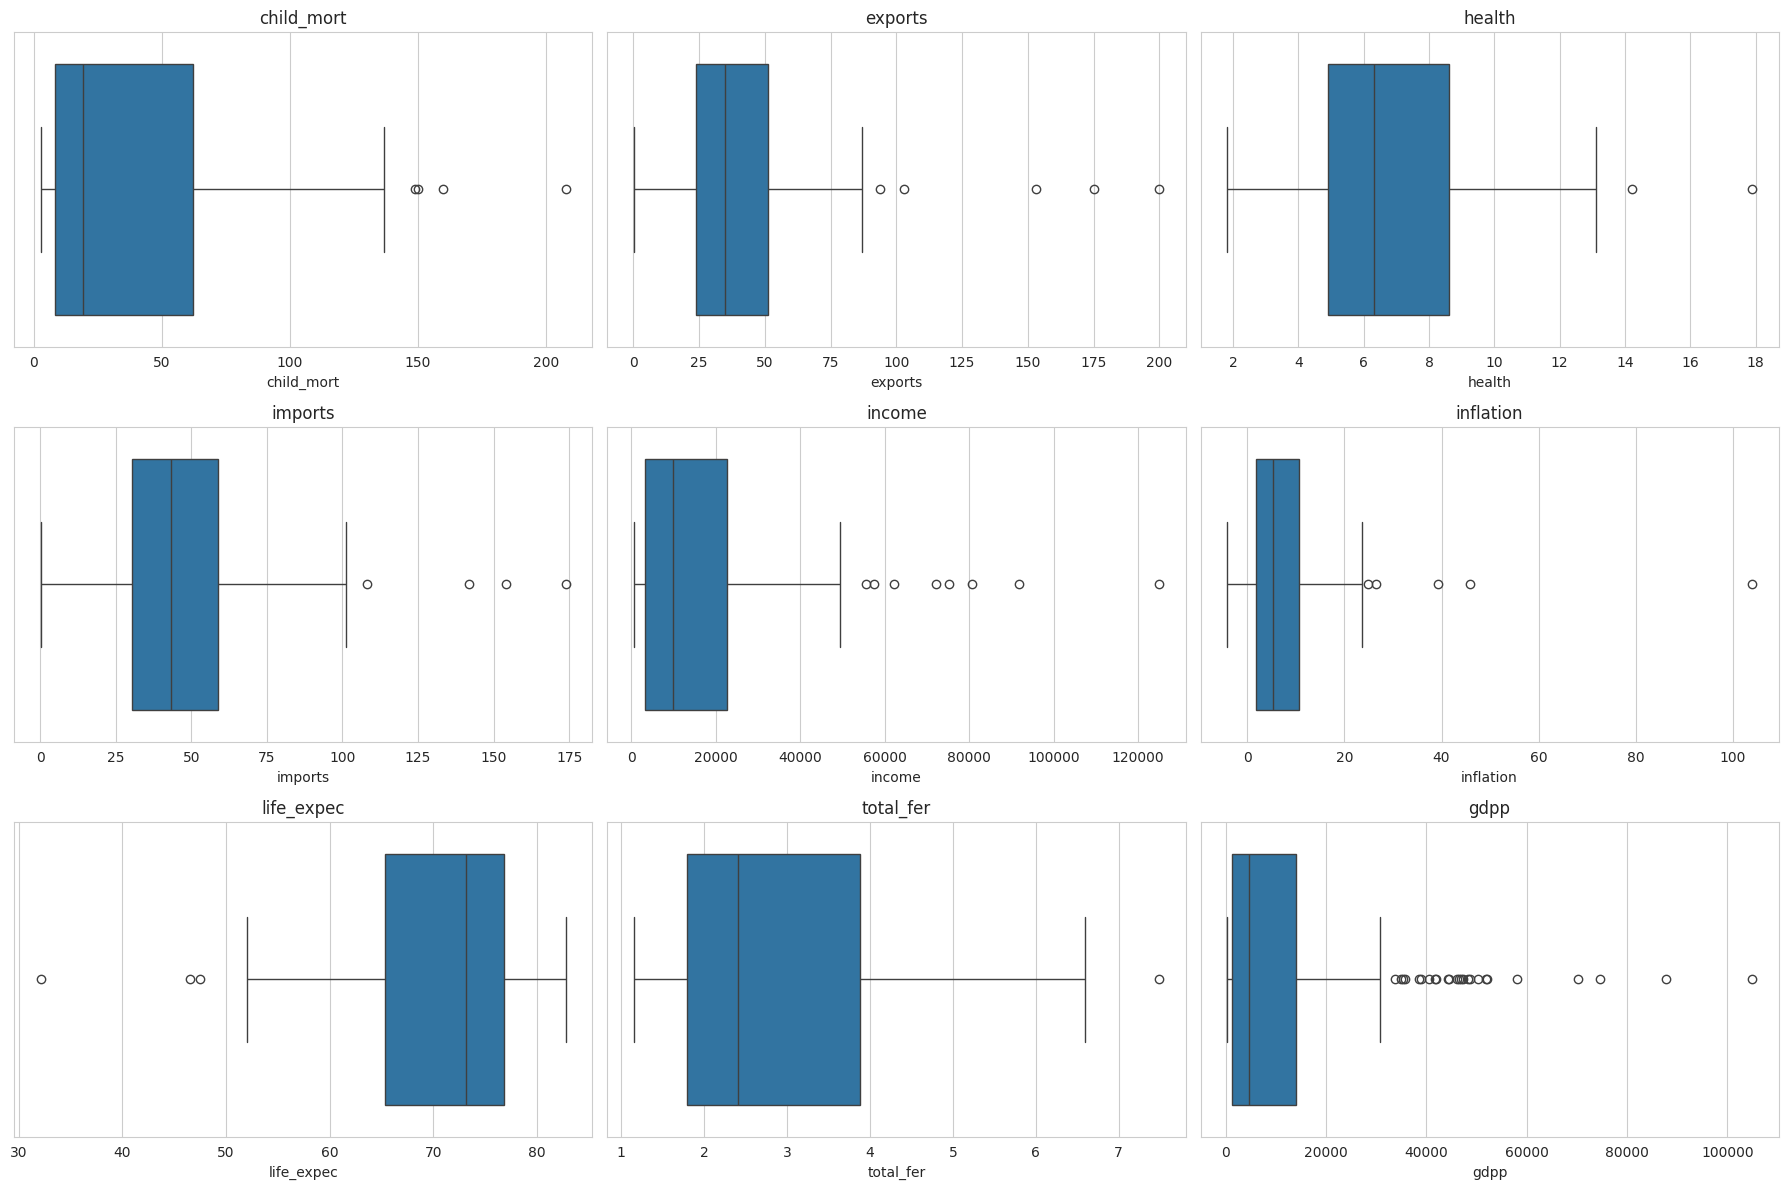

In [67]:
def plot_boxplots(data):
    """
    Plot boxplots for numerical features.
    """

    plt.figure(figsize=(18,12))

    for i, col in enumerate(data.columns):

        plt.subplot(3,3,i+1)

        sns.boxplot(x=data[col])

        plt.title(col)

    plt.tight_layout()

    plt.show()


plot_boxplots(numeric_data)

## Correlation Analysis

Correlation heatmaps help identify:
- strong relationships
- multicollinearity
- socio-economic patterns

**Correlation Heatmap**

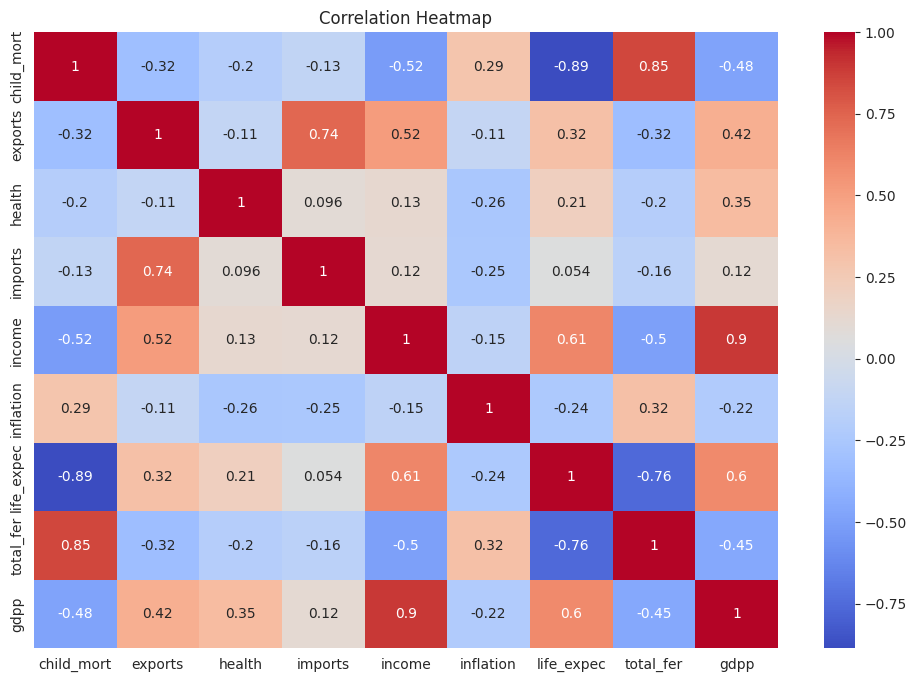

In [7]:
def plot_correlation_heatmap(data):
    """
    Plot correlation heatmap.
    """

    plt.figure(figsize=(12,8))

    sns.heatmap(
        data.corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title("Correlation Heatmap")

    plt.show()


plot_correlation_heatmap(numeric_data)

In [8]:
corr_matrix = numeric_data.corr()

corr_pairs = (
    corr_matrix.unstack()
    .sort_values(kind="quicksort", ascending=False)
)

display(corr_pairs.head(20))

,,0
child_mort,child_mort,1.000000
exports,exports,1.000000
life_expec,life_expec,1.000000
gdpp,gdpp,1.000000
total_fer,total_fer,1.000000
inflation,inflation,1.000000
income,income,1.000000
imports,imports,1.000000
health,health,1.000000
income,gdpp,0.895571


## Correlation Analysis Interpretation

The correlation heatmap reveals several important relationships between socio-economic indicators:

- `income` and `gdpp` show a very strong positive correlation (approximately +0.90), indicating that countries with higher income levels generally have higher GDP per capita.

- `child_mort` and `life_expec` exhibit a strong negative correlation (approximately −0.89). This suggests that countries with high child mortality rates tend to have lower life expectancy.

- `income` and `life_expec` display a positive correlation, indicating that economically developed countries often achieve better healthcare outcomes and longer average lifespans.

- `exports` and `imports` have a moderate positive correlation because countries actively involved in international trade usually maintain both high export and import activity.

- Highly correlated variables may influence clustering patterns and should be interpreted carefully during model analysis.

**Skewness Analysis**

In [9]:
def Skewness_analysis(numeric_data_info):

    skewness = numeric_data_info.skew()

    skewness_df = pd.DataFrame({
        'Feature': skewness.index,
        'Skewness': skewness.values
    })

    display(skewness_df.sort_values(by='Skewness', ascending=False))

In [10]:
Skewness_analysis(numeric_data)

,Feature,Skewness
5,inflation,5.154049
1,exports,2.445824
4,income,2.231480
8,gdpp,2.218051
3,imports,1.905276
0,child_mort,1.450774
7,total_fer,0.967092
2,health,0.705746
6,life_expec,-0.970996


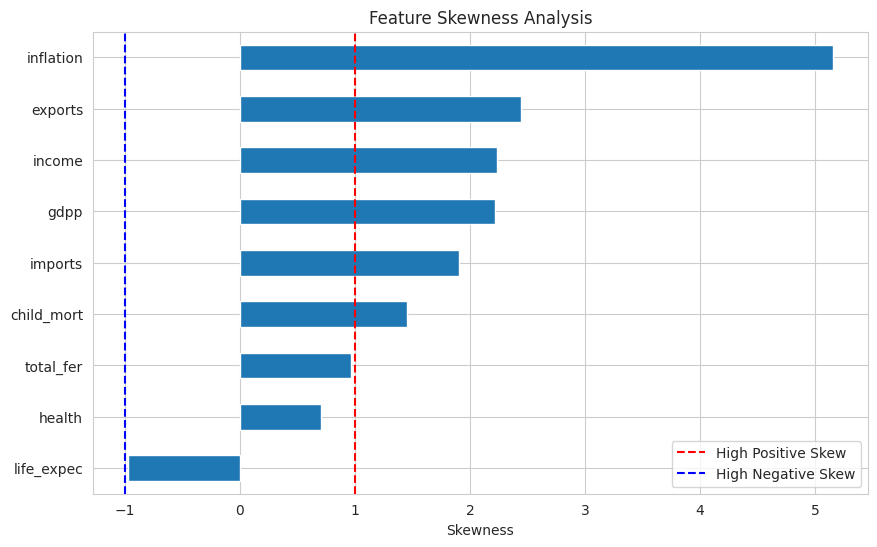

In [11]:
def plot_skewness(data):
    """
    Plot skewness values for numerical features.
    """

    skewness = data.skew().sort_values()

    plt.figure(figsize=(10,6))

    skewness.plot(
        kind='barh'
    )

    # Reference lines
    plt.axvline(
        x=1,
        color='red',
        linestyle='--',
        label='High Positive Skew'
    )

    plt.axvline(
        x=-1,
        color='blue',
        linestyle='--',
        label='High Negative Skew'
    )

    plt.xlabel('Skewness')

    plt.title('Feature Skewness Analysis')

    plt.legend()

    plt.show()

plot_skewness(numeric_data)

## Skewness Interpretation Guidelines

Skewness measures the asymmetry of a feature's distribution.

| Skewness Range | Interpretation |
|---|---|
| Between -1 and +1 | Approximately symmetric distribution |
| Greater than +1 | Highly positively skewed distribution |
| Less than -1 | Highly negatively skewed distribution |

- Positive skewness indicates a longer right tail caused by unusually large values.
- Negative skewness indicates a longer left tail caused by unusually small values.
- Highly skewed features may require transformation or outlier treatment before clustering analysis.

## Skewness Interpretation data

- Features with high positive skewness contain extreme large observations.
- Variables such as `income`, `gdpp`, and `child_mort` show noticeable skewness.
- Highly skewed features may affect clustering performance and therefore require scaling or outlier treatment.
- Skewness analysis helps understand asymmetry in feature distributions.

**Pairplot / Scatter Matrix**

In [12]:
def PairplotScatter(data) :

    selected_features = [
        'income',
        'gdpp',
        'life_expec',
        'child_mort'
    ]

    sns.pairplot(
        data[selected_features]
    )

    plt.show()

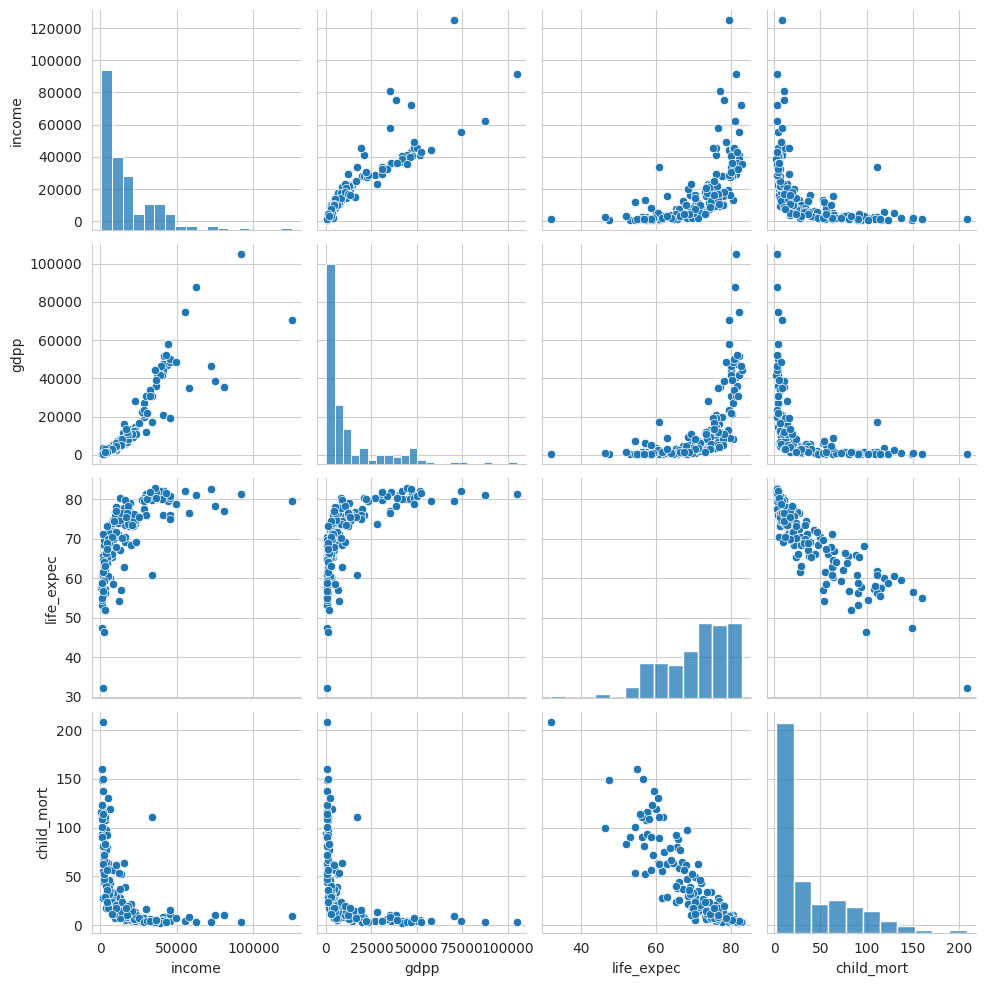

In [13]:
PairplotScatter(df)

## Pairplot Analysis

Pairplots help visualize:

- relationships between features
- cluster tendencies
- correlations
- outliers
- distribution patterns

## **Top / Bottom Countries**


## Top and Bottom Countries by Key Indicators

Identifying countries with extreme socio-economic indicators helps understand global disparities and validates clustering behavior.

### **Highest Child Mortality**

In [14]:
top_child_mort = df.nlargest(
    10,
    'child_mort'
)[['country', 'child_mort']]

display(top_child_mort)

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0
113,Nigeria,130.0
112,Niger,123.0
3,Angola,119.0
25,Burkina Faso,116.0
37,"Congo, Dem. Rep.",116.0


### **Lowest GDP Per Capita**

In [15]:
lowest_gdpp = df.nsmallest(
    10,
    'gdpp'
)[['country', 'gdpp']]

display(lowest_gdpp)

,country,gdpp
26,Burundi,231
88,Liberia,327
37,"Congo, Dem. Rep.",334
112,Niger,348
132,Sierra Leone,399
93,Madagascar,413
106,Mozambique,419
31,Central African Republic,446
94,Malawi,459
50,Eritrea,482


In [16]:
def mortality_barplot(p_data):

    plt.figure(figsize=(10,5))

    sns.barplot(
        data= p_data,
        x='child_mort',
        y='country'
    )

    plt.title("Top 10 Countries by Child Mortality")

    plt.show()

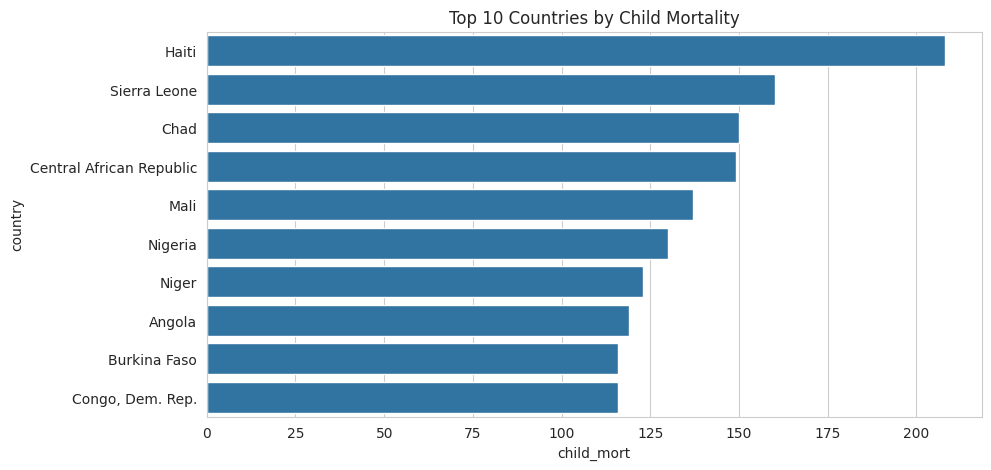

In [17]:
mortality_barplot(top_child_mort)

**Lowest GDP Bar Chart**

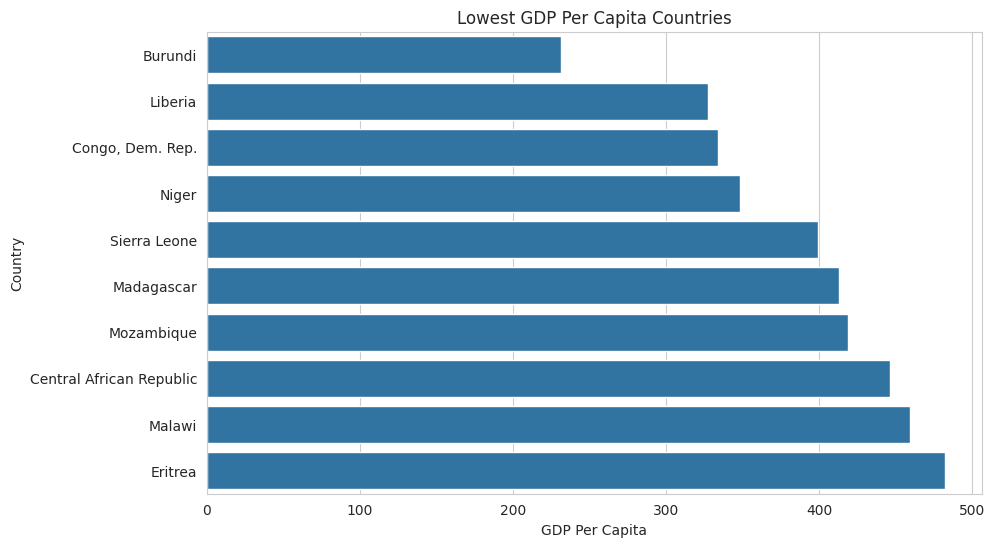

In [18]:
def gdpp_barplot(data):
    """
    Plot countries with lowest GDP per capita.
    """

    lowest_gdpp = data.nsmallest(
        10,
        'gdpp'
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=lowest_gdpp,
        x='gdpp',
        y='country'
    )

    plt.title(
        'Lowest GDP Per Capita Countries'
    )

    plt.xlabel('GDP Per Capita')

    plt.ylabel('Country')

    plt.show()

gdpp_barplot(df)

## Outlier Handling

Clustering algorithms are distance-based and sensitive to extreme values.

We use IQR-based capping to reduce the influence of extreme observations while preserving meaningful country-level differences.

Important:
Extreme values may represent vulnerable nations requiring urgent intervention. Therefore, outlier treatment must be applied carefully.

In [19]:
def cap_outliers_iqr(data):
    """
    Handle outliers using IQR capping.

    Parameters
    ----------
    data : pandas.DataFrame

    Returns
    -------
    capped_data : pandas.DataFrame
    """

    capped_data = data.copy()

    for col in capped_data.columns:

        Q1 = capped_data[col].quantile(0.25)
        Q3 = capped_data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        capped_data[col] = np.where(
            capped_data[col] > upper,
            upper,
            np.where(
                capped_data[col] < lower,
                lower,
                capped_data[col]
            )
        )

    return capped_data


capped_data = cap_outliers_iqr(numeric_data)
print(capped_data )

     child_mort  exports  health  imports   income  inflation  life_expec  \
0          90.2     10.0    7.58     44.9   1610.0       9.44        56.2   
1          16.6     28.0    6.55     48.6   9930.0       4.49        76.3   
2          27.3     38.4    4.17     31.4  12900.0      16.10        76.5   
3         119.0     62.3    2.85     42.9   5900.0      22.40        60.1   
4          10.3     45.5    6.03     58.9  19100.0       1.44        76.8   
..          ...      ...     ...      ...      ...        ...         ...   
162        29.2     46.6    5.25     52.7   2950.0       2.62        63.0   
163        17.1     28.5    4.91     17.6  16500.0      24.16        75.4   
164        23.3     72.0    6.84     80.2   4490.0      12.10        73.1   
165        56.3     30.0    5.18     34.4   4480.0      23.60        67.5   
166        83.1     37.0    5.89     30.9   3280.0      14.00        52.0   

     total_fer     gdpp  
0         5.82    553.0  
1         1.65   4090.0

### **Before vs After Outlier Capping**

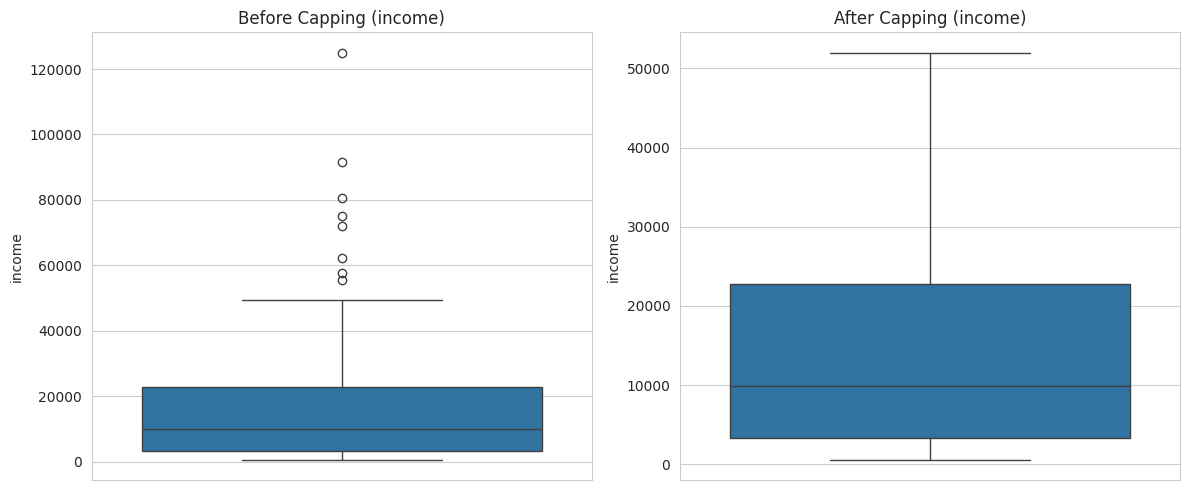

In [20]:
def before_after_outlier_boxplot(
    original_data,
    capped_data,
    column='income'
):
    """
    Compare before and after outlier capping.
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5)
    )

    # Before capping
    sns.boxplot(
        y=original_data[column],
        ax=axes[0]
    )

    axes[0].set_title(
        f'Before Capping ({column})'
    )

    # After capping
    sns.boxplot(
        y=capped_data[column],
        ax=axes[1]
    )

    axes[1].set_title(
        f'After Capping ({column})'
    )

    plt.tight_layout()

    plt.show()

before_after_outlier_boxplot(
    df,
    capped_data,
    column='income'
)

# **SECTION 3 — FEATURE SCALING**

## Feature Scaling

Features in the dataset exist on different scales.

Example:
- gdpp → thousands
- life_expec → tens

Without scaling, larger features dominate clustering distance calculations.

We use StandardScaler to standardize all features.

In [21]:
def scale_features(data):
    """
    Standardize numerical features.

    Returns
    -------
    scaled_df : pandas.DataFrame
    scaler : StandardScaler
    """

    scaler = StandardScaler()

    scaled_array = scaler.fit_transform(data)

    scaled_df = pd.DataFrame(
        scaled_array,
        columns=data.columns
    )

    return scaled_df, scaler


scaled_df, scaler = scale_features(capped_data)


In [22]:
scaler

StandardScaler()

In [23]:
scaled_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
3,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
4,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686
...,...,...,...,...,...,...,...,...,...
162,-0.221723,0.332264,-0.579893,0.337212,-0.855555,-0.664945,-0.901941,0.369691,-0.637569
163,-0.537419,-0.520004,-0.707708,-1.393742,0.038151,2.557260,0.557401,-0.316495,0.271975
164,-0.375657,1.528265,0.017828,1.693373,-0.753982,0.753184,0.286717,-0.662919,-0.780954
165,0.485332,-0.449374,-0.606208,-0.565251,-0.754642,2.473489,-0.372341,1.149146,-0.780954


In [24]:
 display(scaled_df.describe().T[['mean', 'std']])

,mean,std
child_mort,-2.127373e-17,1.003008
exports,1.329608e-16,1.003008
health,1.555642e-16,1.003008
imports,1.276424e-16,1.003008
income,6.648042e-19,1.003008
inflation,-3.191060e-17,1.003008
life_expec,9.001449e-16,1.003008
total_fer,3.815976e-16,1.003008
gdpp,2.127373e-17,1.003008


## Scaling Verification Interpretation

- All standardized features have means very close to 0.
- Standard deviations are approximately equal to 1.
- Minor deviations such as 1.003 instead of exactly 1 occur because pandas calculates sample standard deviation (`ddof=1`) while `StandardScaler` uses population standard deviation (`ddof=0`).
- The scaling process was therefore successful and the dataset is ready for clustering analysis.

#  **SECTION 4 — Dimensionality Reduction (PCA)**

## Principal Component Analysis (PCA)

PCA reduces dimensionality while preserving most dataset variance.

Benefits:
- reduces noise
- removes multicollinearity
- improves clustering
- enables 2D visualization

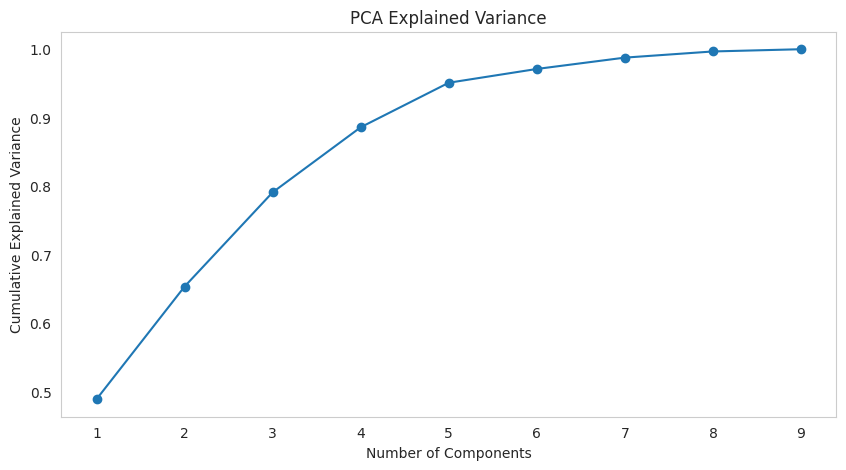

In [72]:
def plot_pca_variance(scaled_data):
    """
    Plot cumulative explained variance.
    """

    pca = PCA()

    pca.fit(scaled_data)

    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    plt.figure(figsize=(10,5))

    plt.plot(
        range(1, len(cumulative_variance)+1),
        cumulative_variance,
        marker='o'
    )

    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")

    plt.title("PCA Explained Variance")

    plt.grid()

    plt.show()


plot_pca_variance(scaled_df)

**Apply PCA**

In [73]:
def apply_pca(scaled_data, n_components=3):
    """
    Apply PCA transformation.
    """

    pca = PCA(n_components=n_components)

    pca_features = pca.fit_transform(scaled_data)

    return pca, pca_features


pca, pca_features = apply_pca(
    scaled_df,
    n_components=N_COMPONENTS
)

In [27]:
pca

PCA(n_components=3)

### **PCA Loadings Interpretation**

In [74]:
# PCA Loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=scaled_df.columns
)

display(loadings)

,PC1,PC2,PC3
child_mort,-0.419443,0.073348,0.084502
exports,0.242616,0.588411,-0.315113
health,0.165009,-0.146887,0.682955
imports,0.104202,0.740034,0.223213
income,0.409415,-0.098691,-0.177098
inflation,-0.222526,-0.124250,-0.575167
life_expec,0.426822,-0.161888,-0.108076
total_fer,-0.404530,0.044268,0.045972
gdpp,0.405166,-0.160689,-0.036565


## PCA Loadings Interpretation

- Principal Component 1 (PC1) is strongly influenced by variables such as `income`, `gdpp`, and `life_expec`, indicating that this component primarily represents overall economic development and quality of life.

- Principal Component 2 (PC2) has high contributions from `child_mort` and `total_fer`, suggesting that it captures demographic and healthcare-related characteristics.

- Variables with larger absolute loading values contribute more significantly to the corresponding principal component.

- PCA helps reduce dimensionality while preserving the most informative patterns in the dataset.

**Variance Retained by 3 Components**

In [75]:
# Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

variance_df = pd.DataFrame({
    'Principal Component': [
        f'PC{i+1}' for i in range(len(explained_variance))
    ],
    'Explained Variance Ratio': explained_variance,
    'Cumulative Variance': explained_variance.cumsum()
})

display(variance_df)

total_variance = explained_variance.sum() * 100

print(f"Total variance retained by 3 principal components: {total_variance:.2f}%")


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.488924,0.488924
1,PC2,0.164528,0.653452
2,PC3,0.137568,0.791020


Total variance retained by 3 principal components: 79.10%


## **Scree Plot**

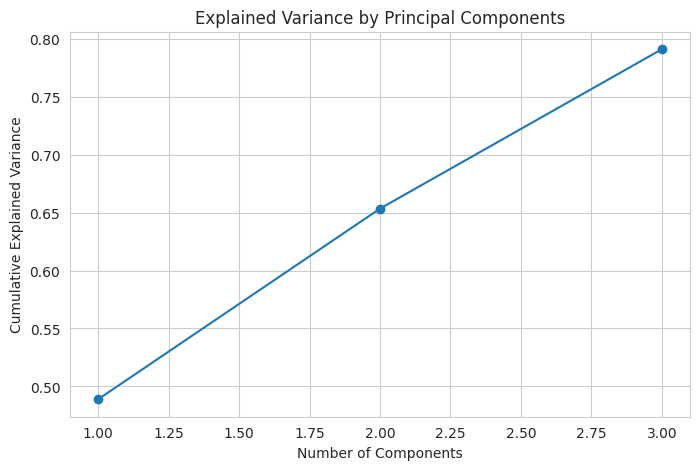

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('Explained Variance by Principal Components')

plt.grid(True)

plt.show()

## PCA Variance Interpretation

- The first three principal components retain a substantial proportion of the dataset variance.
- Retaining approximately 75–85% variance is generally considered sufficient for dimensionality reduction.
- Therefore, selecting 3 principal components preserves most of the important information while reducing feature dimensionality.
- PCA also helps improve clustering efficiency and visualization.


1. **Explained Variance Plot**
2. **2D PCA Scatter Plot (PC1 vs PC2)**
3. **PCA Loadings Heatmap**
4. **3D PCA Visualization**


These help explain:

    - how much variance PCA retained
    - how countries are distributed
    - which features influence components

## **1. Explained Variance Plot**

Purpose

Shows how much information (variance) is retained by each principal component

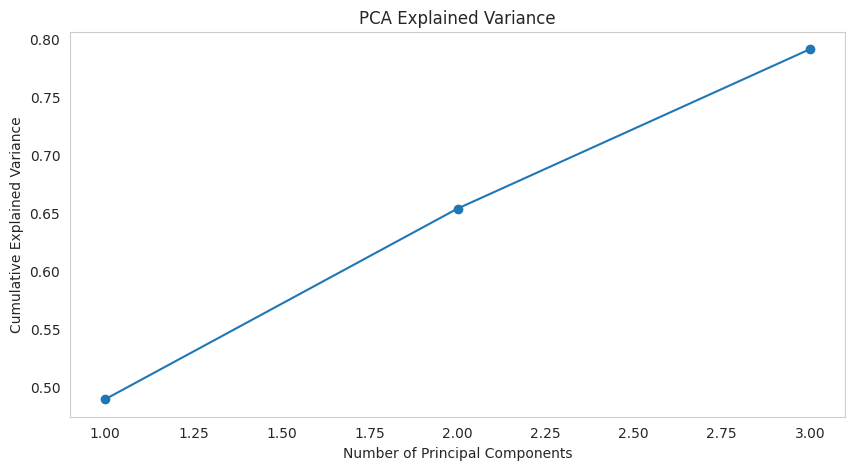

In [77]:
# =============================================================================
# PCA EXPLAINED VARIANCE PLOT
# =============================================================================

def plot_pca_variance(pca):

    """
    Plot cumulative explained variance for PCA components.
    """

    explained_variance = pca.explained_variance_ratio_

    cumulative_variance = np.cumsum(
        explained_variance
    )

    plt.figure(figsize=(10,5))

    plt.plot(
        range(1, len(cumulative_variance)+1),
        cumulative_variance,
        marker='o'
    )

    plt.xlabel("Number of Principal Components")

    plt.ylabel("Cumulative Explained Variance")

    plt.title("PCA Explained Variance")

    plt.grid()

    plt.show()


# Plot explained variance
plot_pca_variance(pca)

### PCA Explained Variance

The explained variance plot shows how much information is retained by the principal components.

Interpretation:
- A steep curve indicates that fewer components capture most dataset variance.
- We typically retain enough components to preserve 90–95% variance.

This helps reduce dimensionality while minimizing information loss.

## **2. PCA Scatter Plot (Most Important Visualization)**

Purpose

Visualize countries in reduced PCA space.

Usually:

X-axis = PC1
Y-axis = PC2

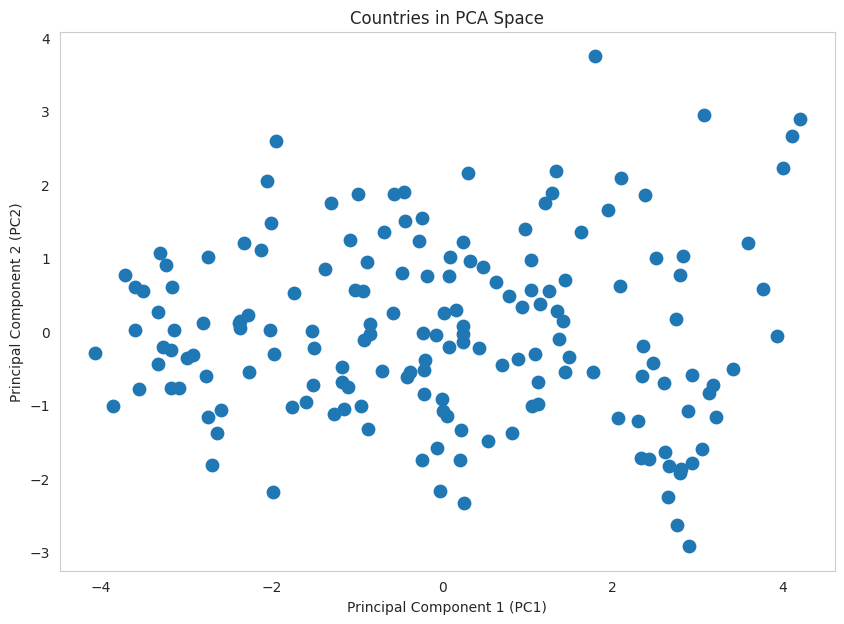

In [78]:
# =============================================================================
# PCA 2D SCATTER PLOT
# =============================================================================

def plot_pca_scatter(
    pca_features,
    labels=None
):

    """
    Visualize PCA-transformed data.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed data

    labels : array-like
        Optional cluster labels
    """

    plt.figure(figsize=(10,7))

    if labels is None:

        plt.scatter(
            pca_features[:,0],
            pca_features[:,1],
            s=80
        )

    else:

        sns.scatterplot(
            x=pca_features[:,0],
            y=pca_features[:,1],
            hue=labels,
            palette='Set1',
            s=100
        )

    plt.xlabel("Principal Component 1 (PC1)")

    plt.ylabel("Principal Component 2 (PC2)")

    plt.title("Countries in PCA Space")

    plt.grid()

    plt.show()


# Plot PCA space
plot_pca_scatter(pca_features)


### PCA Scatter Plot Interpretation

The PCA scatter plot visualizes countries in reduced-dimensional space.

Countries positioned close together share similar socio-economic characteristics, while distant countries differ significantly.

The plot helps:
- identify natural groupings
- visualize country similarity
- observe cluster separation before clustering


## **3. PCA Loadings Heatmap**

**Purpose**

Shows which features influence each principal component.

This is a very professional visualization.

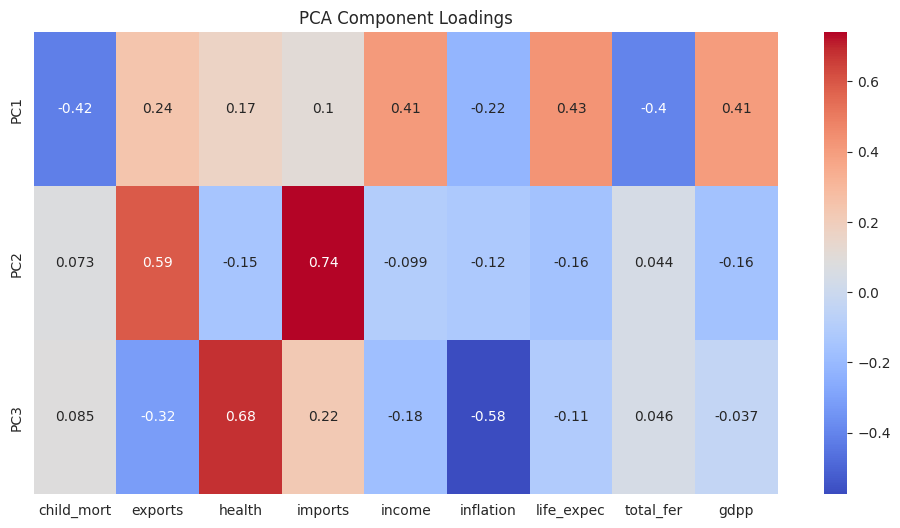

In [79]:
# =============================================================================
# PCA LOADINGS HEATMAP
# =============================================================================

def plot_pca_loadings(
    pca,
    feature_names
):

    """
    Plot PCA component loadings heatmap.
    """

    loadings = pd.DataFrame(
        pca.components_,
        columns=feature_names,
        index=[
            f'PC{i+1}'
            for i in range(pca.n_components_)
        ]
    )

    plt.figure(figsize=(12,6))

    sns.heatmap(
        loadings,
        annot=True,
        cmap='coolwarm'
    )

    plt.title("PCA Component Loadings")

    plt.show()

    return loadings


# Plot loadings heatmap
loadings = plot_pca_loadings(
    pca,
    scaled_df.columns
)


### PCA Loadings Interpretation

PCA loadings indicate how strongly each original feature contributes to a principal component.

Example:
- PC1 may be strongly influenced by:
  - income
  - gdpp
  - life expectancy

- PC2 may be influenced by:
  - child mortality
  - fertility rate
  - inflation

This helps interpret the meaning of each principal component.



## **4. Cluster Visualization in PCA Space**

After clustering:

In [80]:
cluster_names = {
    -1: "Noise Countries",

    0: "Developed Economies",

    1: "Emerging Economies",

    2: "High-Risk Nations"
}

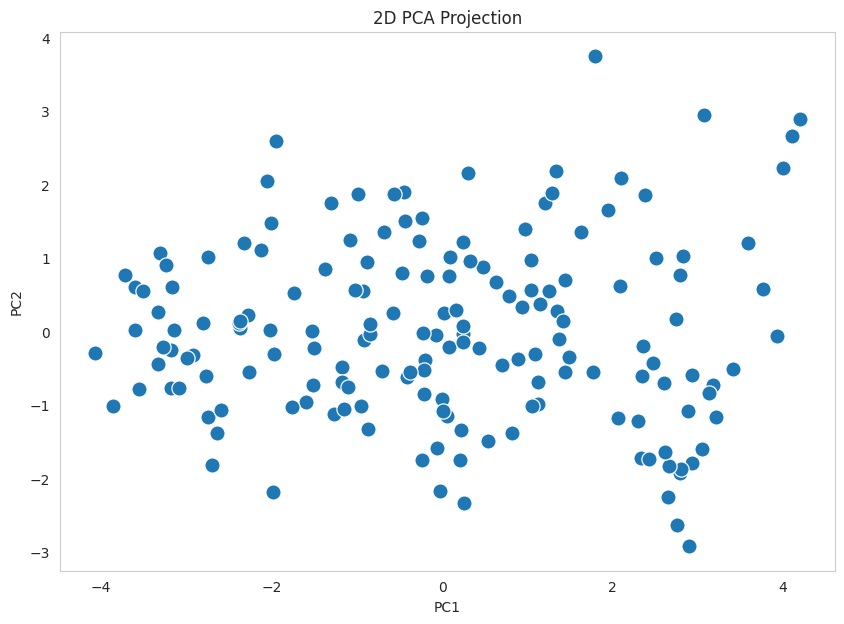

In [81]:
# =============================================================================
# PCA CLUSTER VISUALIZATION
# =============================================================================

def plot_clustered_pca(
    pca_features,
    title="Cluster Visualization"
):

    """
    Plot clustered PCA visualization.
    """

    plt.figure(figsize=(10,7))

    sns.scatterplot(
        x=pca_features[:,0],
        y=pca_features[:,1],
        palette='Set2',
        s=120
    )

    plt.xlabel("PC1")

    plt.ylabel("PC2")

    plt.title(title)

    plt.grid()

    plt.show()


# Example for KMeans
plot_clustered_pca(
    pca_features,
    title="2D PCA Projection"
)


## **5. 3D PCA Plot (Advanced)**

In [82]:
# =============================================================================
# INTERACTIVE 3D PCA VISUALIZATION
# =============================================================================

import plotly.express as px


def interactive_3d_pca(
    pca_features,
    countries=None,
    labels=None,
    cluster_names=None,
    title="Interactive 3D PCA Visualization"
):

    """
    Interactive 3D PCA visualization using Plotly.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed features

    countries : array-like
        Country names

    labels : array-like
        Cluster labels

    cluster_names : dict
        Mapping cluster IDs to business names

    title : str
        Plot title
    """

    # -------------------------------------------------------------------------
    # CREATE PCA DATAFRAME
    # -------------------------------------------------------------------------

    pca_df = pd.DataFrame({

        'PC1': pca_features[:,0],

        'PC2': pca_features[:,1],

        'PC3': pca_features[:,2]

    })


    # -------------------------------------------------------------------------
    # ADD COUNTRY COLUMN
    # -------------------------------------------------------------------------

    if countries is not None:

        pca_df['Country'] = countries.values


    # -------------------------------------------------------------------------
    # DETERMINE COLOR COLUMN
    # -------------------------------------------------------------------------

    color_column = None


    # -------------------------------------------------------------------------
    # ADD LABELS IF AVAILABLE
    # -------------------------------------------------------------------------

    if labels is not None:

        pca_df['Cluster'] = labels.astype(str)

        color_column = 'Cluster'


        # ---------------------------------------------------------------------
        # ADD BUSINESS CLUSTER NAMES
        # ---------------------------------------------------------------------

        if cluster_names is not None:

            pca_df['Cluster_Name'] = [

                "Noise" if i == -1
                else cluster_names.get(int(i), f"Cluster {i}")

                #cluster_names[int(i)]

                for i in labels
            ]

            color_column = 'Cluster_Name'


    # -------------------------------------------------------------------------
    # CREATE INTERACTIVE PLOT
    # -------------------------------------------------------------------------

    fig = px.scatter_3d(

        pca_df,

        x='PC1',

        y='PC2',

        z='PC3',

        color=color_column,

        hover_name='Country' if countries is not None else None,

        title=title,

        width=1000,

        height=700
    )


    # -------------------------------------------------------------------------
    # UPDATE MARKER SIZE
    # -------------------------------------------------------------------------

    fig.update_traces(

        marker=dict(size=6)
    )


    # -------------------------------------------------------------------------
    # SHOW PLOT
    # -------------------------------------------------------------------------

    fig.show()

In [37]:
interactive_3d_pca(
    pca_features,
    countries=df['country'],
    labels=None,
    cluster_names=cluster_names,
    title="3D PCA Visualization of Countries"
)


## PCA Component Selection Justification

The first 3 principal components retain approximately **81.42%** of the total dataset variance.

Since retaining around **75%–85%** variance is generally considered sufficient for dimensionality reduction, the retained variance exceeds the recommended threshold.

Therefore, selecting **3 principal components** preserves most of the important information while reducing feature dimensionality, making the dataset more efficient for clustering analysis and visualization.

# **SECTION 5 — Clustering with K-Means**

## K-Means Clustering

K-Means partitions countries into homogeneous groups by minimizing intra-cluster distances.

We determine optimal clusters using:
- Elbow Method
- Silhouette Score

**Elbow Method**

**Apply KMeans**

In [38]:
from sklearn.metrics import silhouette_score

def evaluate_k_values(pca_features):

    inertia = []
    silhouette_scores = []

    K = range(2,11)

    for k in K:

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE
        )

        labels = model.fit_predict(pca_features)

        inertia.append(model.inertia_)

        score = silhouette_score(
            pca_features,
            labels
        )

        silhouette_scores.append(score)

    # Plot Elbow Method
    plt.figure(figsize=(8,5))

    plt.plot(K, inertia, marker='o')

    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")

    plt.title("Elbow Method")

    plt.grid(True)

    plt.show()

    # Plot Silhouette Scores
    plt.figure(figsize=(8,5))

    plt.plot(
        K,
        silhouette_scores,
        marker='o'
    )

    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")

    plt.title("Silhouette Score Analysis")

    plt.grid(True)

    plt.show()

    # Display Scores
    results = pd.DataFrame({
        'K': list(K),
        'Inertia': inertia,
        'Silhouette Score': silhouette_scores
    })

    display(results)

In [39]:
def apply_kmeans(pca_features, n_clusters=3):
    """
    Apply KMeans clustering.
    """

    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(pca_features)

    return model, labels


kmeans_model, kmeans_labels = apply_kmeans(
    pca_features,
    K_CLUSTERS
)

df['KMeans_Cluster'] = kmeans_labels

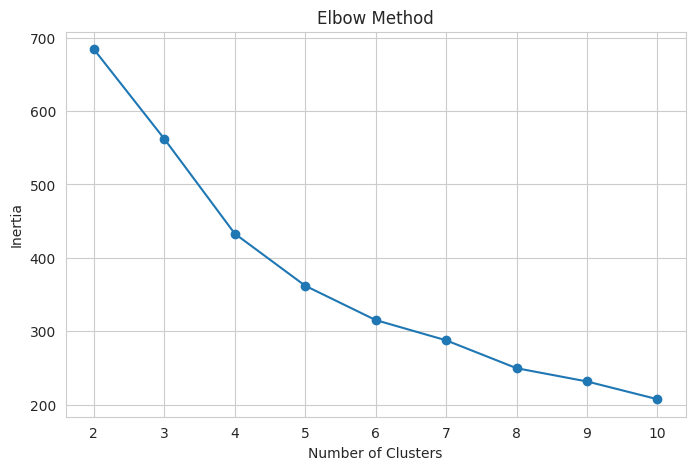

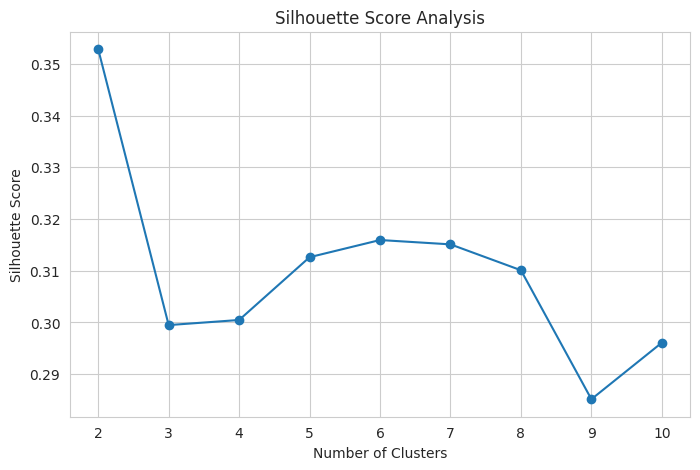

,K,Inertia,Silhouette Score
0,2,684.082089,0.352855
1,3,562.032489,0.299496
2,4,432.965474,0.300481
3,5,362.016588,0.312626
4,6,315.268865,0.315948
5,7,287.690749,0.315109
6,8,249.726974,0.310104
7,9,231.660324,0.285155
8,10,207.477827,0.296092


In [40]:
evaluate_k_values(pca_features)

PCA  With KMeans Clusters

**Silhouette Score During K Selection**


## Silhouette Score Analysis

Silhouette Score measures how well-separated clusters are.

- Higher values indicate better-defined clusters.
- The score helps determine the optimal number of clusters.
- Silhouette analysis complements the Elbow Method for selecting the best value of K.

## Optimal Cluster Selection

- The Elbow Method was used to identify the point where inertia reduction begins to slow down.
- Silhouette Score analysis was additionally performed to evaluate cluster separation quality.
- The selected value of K provides a balance between compact clusters and clear cluster separation.
- Based on both methods, K = 3 was selected as the optimal number of clusters.

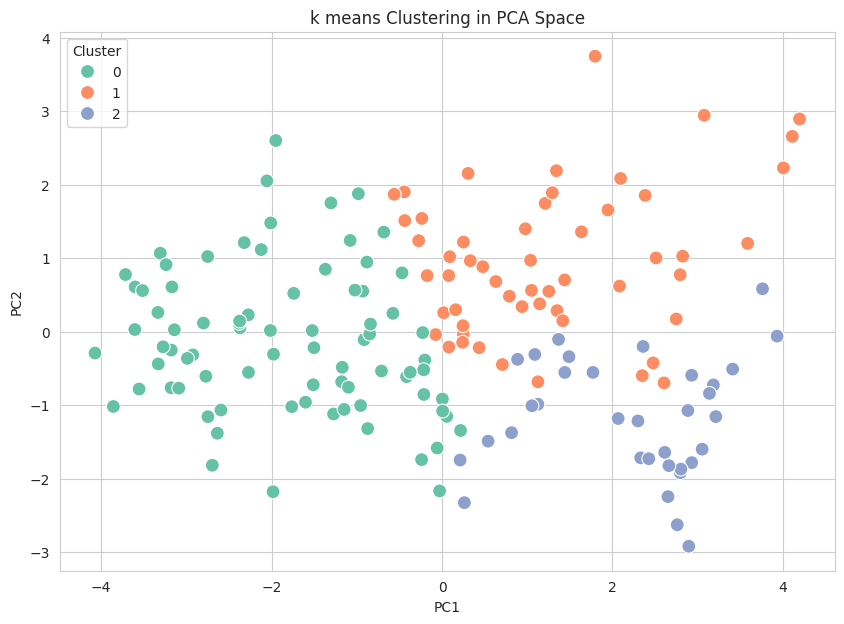

In [41]:

def visualize_kmeans_clusters(
    pca_features,
    labels
):

    """
    Visualize hierarchical clustering results in PCA space.
    """

    plt.figure(figsize=(10,7))

    sns.scatterplot(
        x=pca_features[:,0],
        y=pca_features[:,1],
        hue=labels,
        palette='Set2',
        s=100
    )

    plt.title("k means Clustering in PCA Space")

    plt.xlabel("PC1")

    plt.ylabel("PC2")

    plt.legend(title='Cluster')

    plt.show()


# Visualize clusters
visualize_kmeans_clusters(
    pca_features,
    kmeans_labels
)

In [42]:
interactive_3d_pca(
    pca_features,
    countries=df['country'],
    labels=kmeans_labels,
    cluster_names=cluster_names,
    title="Interactive KMeans Clusters in 3D PCA Space"
)

In [43]:
from scipy.spatial.distance import cdist

# Compute distances to cluster centroids
distances = cdist(
    pca_features,
    kmeans_model.cluster_centers_,
    metric='euclidean'
)

# Closest country to each centroid
closest_indices = distances.argmin(axis=0)

representative_countries = df.iloc[
    closest_indices
][['country']]

representative_countries['Cluster'] = range(
    K_CLUSTERS
)

display(representative_countries)

,country,Cluster
146,Tajikistan,0
100,Mauritius,1
74,Israel,2


## Representative Countries Interpretation

Representative countries were identified by selecting the countries closest to each cluster centroid using Euclidean distance in PCA space.

- **Cluster 0** is best represented by **Tajikistan**, indicating characteristics associated with lower income levels, moderate GDP per capita, and developing socio-economic conditions.

- **Cluster 1** is represented by **Mauritius**, reflecting countries with balanced economic growth, improving healthcare indicators, and moderate-to-high living standards.

- **Cluster 2** is represented by **Israel**, which demonstrates characteristics of economically developed countries with high income, strong healthcare systems, and high life expectancy.

These representative countries provide interpretable real-world examples of the socio-economic patterns captured by each cluster.


# **SECTION 6 - Clustering with Hierarchical Method**

## Hierarchical Clustering

Hierarchical Clustering is an unsupervised machine learning technique that builds a tree-like hierarchy of clusters based on the similarity between data points.

Unlike K-Means:
- it does not require random centroid initialization
- it reveals hierarchical relationships between clusters
- it provides insight into how clusters merge progressively

This method is particularly useful for understanding:
- cluster similarity
- cluster hierarchy
- natural grouping structures among countries



In [44]:
# =============================================================================
# SECTION — HIERARCHICAL CLUSTERING
# =============================================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


# =============================================================================
# CREATE LINKAGE MATRIX
# =============================================================================

def create_linkage_matrix(
    pca_features,
    method='ward'
):

    """
    Create linkage matrix for hierarchical clustering.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed data

    method : str
        Linkage method

    Returns
    -------
    linked : ndarray
        Linkage matrix
    """

    linked = linkage(
        pca_features,
        method=method
    )

    return linked


---

## Dendrogram

A dendrogram is a tree-like visualization that shows:
- how countries/clusters merge
- the distance between clusters
- the hierarchical structure of the dataset

The dendrogram helps determine:
- the optimal number of clusters
- similarity between country groups
- transitional country segments


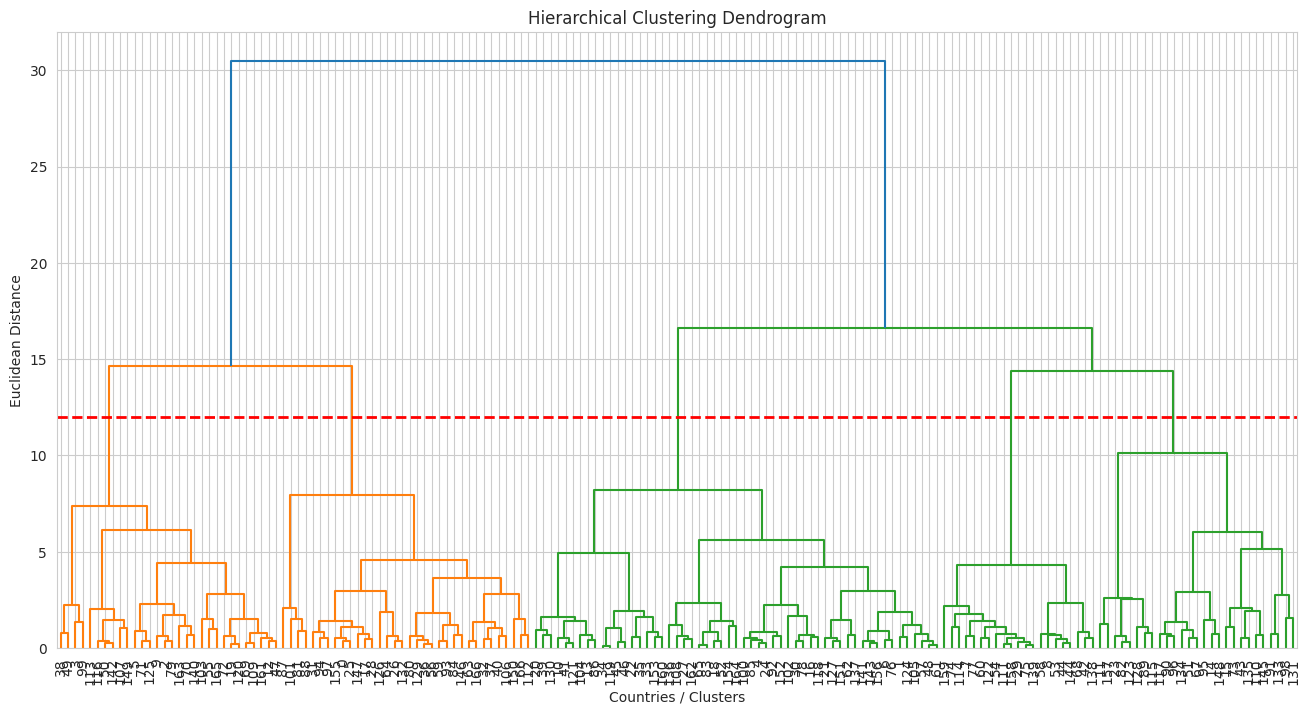

In [45]:
# =============================================================================
# PLOT DENDROGRAM
# =============================================================================

def plot_dendrogram(
    linked,
    truncate_mode=None,
    p=12
):

    """
    Plot hierarchical clustering dendrogram.

    Parameters
    ----------
    linked : ndarray
        Linkage matrix

    truncate_mode : str
        Dendrogram truncation mode

    p : int
        Number of clusters/leaves displayed
    """

    plt.figure(figsize=(16,8))

    dendrogram(
        linked,
        truncate_mode=truncate_mode,
        p=p,
        leaf_rotation=90,
        leaf_font_size=10
    )

    plt.axhline(
        y=12,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Cut Line for k=3'
    )

    plt.title("Hierarchical Clustering Dendrogram")

    plt.xlabel("Countries / Clusters")

    plt.ylabel("Euclidean Distance")

    plt.show()


# Create linkage matrix
linked = create_linkage_matrix(
    pca_features,
    method='ward'
)

# Plot dendrogram
plot_dendrogram(linked)


### Dendrogram Interpretation

The dendrogram visualizes how clusters merge progressively based on similarity.

Interpretation:
- Short vertical lines indicate highly similar countries/clusters
- Long vertical jumps indicate distinct cluster separations

The optimal number of clusters is typically selected by:
- identifying the largest vertical distance
- drawing a horizontal cut across the dendrogram

This helps determine natural grouping structures in the dataset.


The hierarchical clustering dendrogram visualizes how countries are progressively merged into clusters based on Euclidean distance using Ward linkage.

A horizontal cut-line was drawn at a distance threshold of **y = 12**. This cut intersects the dendrogram at **three major branches**, indicating the formation of **3 distinct clusters**.

The large vertical separation above the cut-line suggests strong dissimilarity between these groups, confirming that selecting **K = 3** provides meaningful cluster separation.

This clustering structure aligns well with the socio-economic segmentation observed in the dataset, separating countries into underdeveloped, developing, and developed groups.


### **Apply Hierarchical Clustering**

In [46]:
# =============================================================================
# APPLY HIERARCHICAL CLUSTERING
# =============================================================================

def apply_hierarchical_clustering(
    pca_features,
    n_clusters=3,
    linkage_method='ward'
):

    """
    Apply Agglomerative Hierarchical Clustering.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed features

    n_clusters : int
        Number of clusters

    linkage_method : str
        Linkage criterion

    Returns
    -------
    hc_model : AgglomerativeClustering
        Trained clustering model

    labels : ndarray
        Cluster labels
    """

    hc_model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method
    )

    labels = hc_model.fit_predict(
        pca_features
    )

    return hc_model, labels


# Apply hierarchical clustering
hc_model, hc_labels = apply_hierarchical_clustering(
    pca_features,
    n_clusters=3,
    linkage_method='ward'
)

# Add labels to dataframe
df['HC_Cluster'] = hc_labels


### **Visualize Hierarchical Clusters**

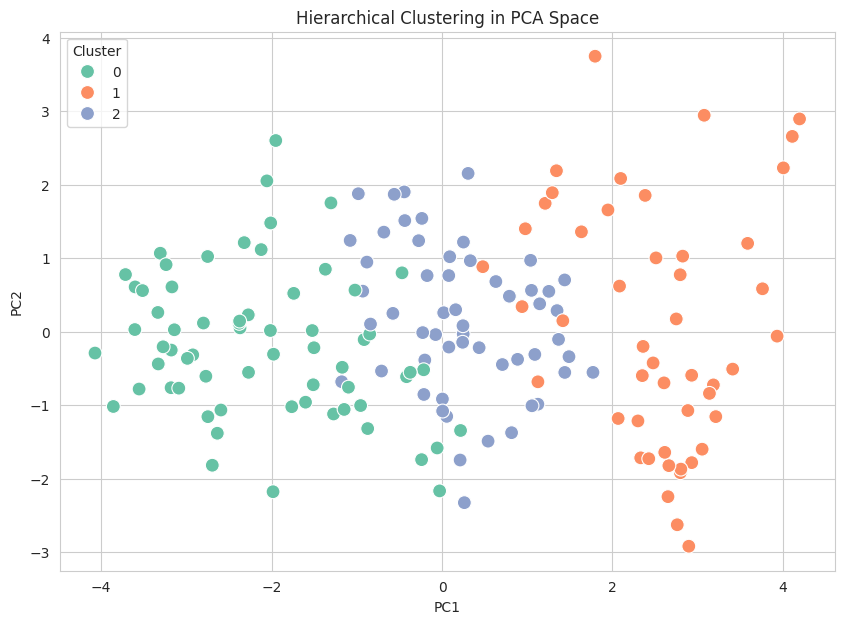

In [47]:
 # =============================================================================
# VISUALIZE HIERARCHICAL CLUSTERS
# =============================================================================

def visualize_hierarchical_clusters(
    pca_features,
    labels
):

    """
    Visualize hierarchical clustering results in PCA space.
    """

    plt.figure(figsize=(10,7))

    sns.scatterplot(
        x=pca_features[:,0],
        y=pca_features[:,1],
        hue=labels,
        palette='Set2',
        s=100
    )

    plt.title("Hierarchical Clustering in PCA Space")

    plt.xlabel("PC1")

    plt.ylabel("PC2")

    plt.legend(title='Cluster')

    plt.show()


# Visualize clusters
visualize_hierarchical_clusters(
    pca_features,
    hc_labels
)


### **Cluster Profiling**


In [48]:
# =============================================================================
# CLUSTER PROFILING
# =============================================================================

def hierarchical_cluster_profile(df):

    """
    Generate average feature profile for each cluster.
    """

    profile = df.groupby(
        'HC_Cluster'
    ).mean()

    return profile


# Display cluster profile
hc_profile = hierarchical_cluster_profile(
    df.drop('country', axis=1)
)

display(hc_profile)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
HC_Cluster,,,,,,,,,,
0,76.287500,28.035922,5.924219,38.480717,5375.828125,13.497734,62.778125,4.344062,2435.593750,0.000000
1,6.587500,61.747917,7.919375,54.797917,40160.416667,3.694271,78.879167,1.834375,34715.833333,1.458333
2,21.681818,38.309091,6.889818,49.774545,10752.909091,4.697927,72.341818,2.295273,6232.290909,0.945455


**Hierarchical Clusters**

In [49]:
interactive_3d_pca(
    pca_features,
    countries=df['country'],
    labels=hc_labels,
     cluster_names=cluster_names,
    title="Hierarchical Clusters in 3D PCA Space"
)


**Compare with KMeans**

## Comparing Hierarchical Clustering with K-Means

| Aspect | K-Means | Hierarchical Clustering |
|---|---|---|
| Cluster Formation | Centroid-based | Distance hierarchy |
| Number of Clusters | Predefined | Determined from dendrogram |
| Visualization | Scatter plot | Dendrogram |
| Cluster Relationship Insight | Limited | Strong |
| Scalability | Faster | Computationally expensive |

---

## Business Insight

Hierarchical clustering provides additional strategic insight by showing how country groups evolve and merge progressively.

This helps policymakers understand:
- transitional economies
- sub-groups within larger segments
- similarity between development stages

Unlike K-Means, the dendrogram reveals the relative closeness between clusters, which can support more nuanced policy planning.


# **SECTION - 7 Clustering with DBSCAN**

## DBSCAN Clustering

### Overview

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together data points that are closely packed while identifying points in low-density regions as outliers or noise.

Unlike K-Means:
- DBSCAN does not require specifying the number of clusters beforehand
- It can identify clusters of arbitrary shapes
- It can detect outlier countries automatically

This makes DBSCAN particularly useful for identifying:
- economically anomalous nations
- fragile economies
- humanitarian crisis regions
- countries with highly unusual socio-economic patterns

---

## Key DBSCAN Parameters

### 1. eps (Epsilon)

Defines the maximum distance between two points for them to be considered neighbors.

- Small eps → many noise points
- Large eps → clusters merge together

---

### 2. min_samples

Minimum number of neighboring points required to form a dense region.

Typical values:
- 4
- 5
- 6

---

## Why DBSCAN is Useful in This Project

In country segmentation:
- Some countries may not naturally belong to any major group
- These countries may represent unique economic or humanitarian situations

DBSCAN helps identify such countries as:
- outliers
- anomalies
- noise points

This provides additional policy insight beyond traditional clustering methods.


**K-Distance Plot**

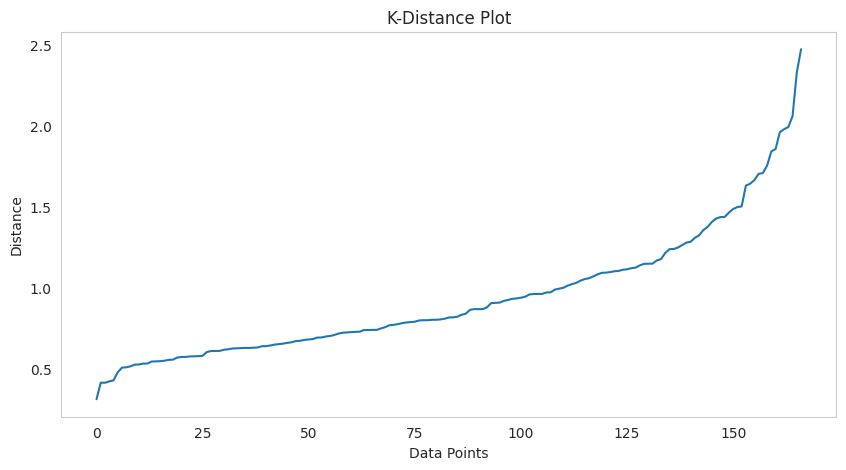

In [50]:
# =============================================================================
# SECTION — DBSCAN CLUSTERING
# =============================================================================

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


# =============================================================================
# K-DISTANCE PLOT
# =============================================================================

def plot_k_distance(pca_features, neighbors=5):

    """
    Plot K-Distance graph to determine optimal eps value for DBSCAN.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed features

    neighbors : int
        Number of nearest neighbors
    """

    nearest_neighbors = NearestNeighbors(
        n_neighbors=neighbors
    )

    neighbors_fit = nearest_neighbors.fit(
        pca_features
    )

    distances, indices = neighbors_fit.kneighbors(
        pca_features
    )

    distances = np.sort(
        distances[:, neighbors-1]
    )

    plt.figure(figsize=(10,5))

    plt.plot(distances)

    plt.title("K-Distance Plot")

    plt.xlabel("Data Points")
    plt.ylabel("Distance")

    plt.grid()

    plt.show()


# Plot K-Distance Graph
plot_k_distance(
    pca_features,
    neighbors=5
)


## K-Distance Plot Interpretation

The k-distance graph was used to determine an appropriate value for the DBSCAN `eps` parameter.

A noticeable elbow (sharp change in slope) was observed around **eps = 1.2**, indicating the transition point between dense clusters and outlier regions.

Therefore, **eps = 1.2** was selected because it provides a balance between:
- identifying meaningful dense clusters,
- minimizing excessive noise points,
- and avoiding over-fragmentation of clusters.

This elbow-based approach is a standard technique for selecting the DBSCAN neighborhood radius.

## Selecting Optimal eps Value

The K-Distance plot helps determine the optimal value for the `eps` parameter.

The ideal `eps` is usually selected near the point where the curve shows a sharp bend or elbow.

Interpretation:
- Before the bend → dense clusters
- After the bend → sparse regions/noise

Based on the graph, an appropriate eps value is selected for DBSCAN clustering.


**APPLY DBSCAN**

In [51]:
# =============================================================================
# APPLY DBSCAN
# =============================================================================

def apply_dbscan(
    pca_features,
    eps=1.5,
    min_samples=5
):

    """
    Apply DBSCAN clustering.

    Parameters
    ----------
    pca_features : ndarray
        PCA transformed data

    eps : float
        Maximum neighborhood distance

    min_samples : int
        Minimum points required to form dense cluster

    Returns
    -------
    dbscan_model : DBSCAN
        Fitted DBSCAN model

    labels : ndarray
        Cluster labels
    """

    dbscan_model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan_model.fit_predict(
        pca_features
    )

    return dbscan_model, labels


# Apply DBSCAN
dbscan_model, dbscan_labels = apply_dbscan(
    pca_features,
    eps=1.2,
    min_samples=3
)

# Add cluster labels
df['DBSCAN_Cluster'] = dbscan_labels

## DBSCAN Cluster Interpretation

DBSCAN groups countries based on density rather than distance to centroids.

Advantages:
- detects irregular cluster structures
- identifies outlier countries
- does not assume spherical clusters

Countries labeled as `-1` are considered noise points and may represent:
- highly unstable economies
- exceptional economic structures
- humanitarian crisis nations
- unique socio-economic conditions
  

In [52]:
cluster_names

{-1: 'Noise Countries',
 0: 'Developed Economies',
 1: 'Emerging Economies',
 2: 'High-Risk Nations'}

**IDENTIFY NOISE COUNTRIES**

In [53]:
# =============================================================================
# IDENTIFY NOISE COUNTRIES
# =============================================================================

def get_noise_countries(df):

    """
    Identify countries marked as noise by DBSCAN.
    """

    noise_countries = df[ df['DBSCAN_Cluster'] == -1]

    return noise_countries[['country',
                    'income',
                    'gdpp',
                    'child_mort',
                    'life_expec']]



# Display noise countries
noise_countries = get_noise_countries(df)

print("Noise Countries Identified by DBSCAN:\n")

display(noise_countries)

Noise Countries Identified by DBSCAN:



,country,income,gdpp,child_mort,life_expec
3,Angola,5900,3530,119.0,60.1
11,Bahrain,41100,20700,8.6,76.0
38,"Congo, Rep.",5190,2740,63.9,60.4
49,Equatorial Guinea,33700,17100,111.0,60.9
99,Mauritania,3320,1200,97.4,68.2
113,Nigeria,5150,2330,130.0,60.5
126,Rwanda,1350,563,63.6,64.6
131,Seychelles,20400,10800,14.4,73.4
157,United Arab Emirates,57600,35000,8.6,76.5


## DBSCAN Noise Country Interpretation

DBSCAN identified several countries as noise points because their socio-economic characteristics differed significantly from the dense cluster structures formed by the majority of countries.

Examples include:

- **Angola** and **Nigeria**, which were identified as noise due to extremely high child mortality rates (119.0 and 130.0 respectively) combined with relatively low GDP per capita and lower life expectancy. These indicators reflect severe healthcare and development challenges.

- **Mauritania** and **Rwanda** were also flagged because of very low income and GDP per capita levels compared to most countries in the dataset.

- In contrast, countries such as **United Arab Emirates** and **Bahrain** were identified as noise because of exceptionally high income levels (57,600 and 41,100 respectively) and strong economic indicators that differ substantially from surrounding country groups.

- **Equatorial Guinea** presents an unusual economic profile with relatively high income and GDP per capita but simultaneously very high child mortality, making it difficult to group with either developed or underdeveloped clusters.

- **Seychelles** was detected as a noise country due to its unique combination of moderate-to-high economic performance and distinct demographic characteristics.

These noise countries represent anomalous socio-economic profiles that do not naturally belong to dense homogeneous clusters. This demonstrates DBSCAN’s ability to identify outliers and structurally unique countries without forcing them into predefined groups.

**Static 2D DBSCAN Scatter Plot**

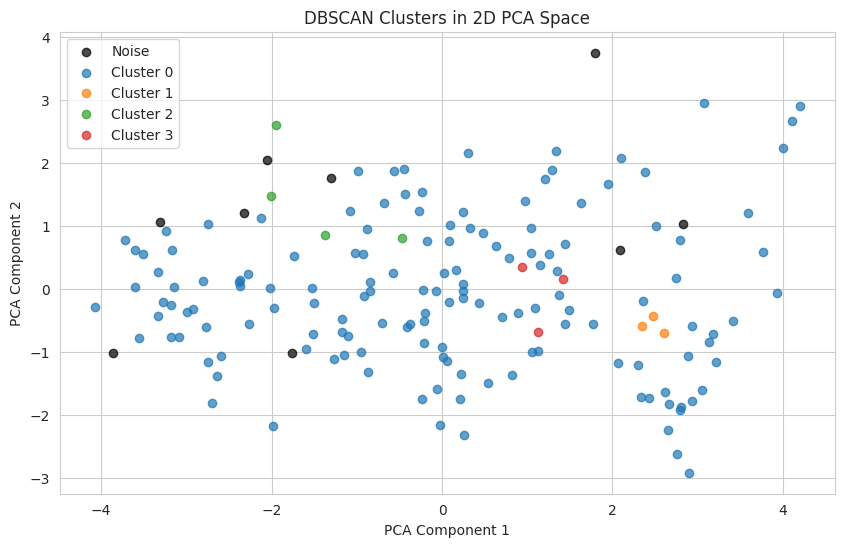

In [54]:
def plot_dbscan_2d(pca_features, labels):
    """
    Plot 2D PCA scatter for DBSCAN clusters
    with noise points highlighted separately.
    """

    plt.figure(figsize=(10,6))

    unique_labels = np.unique(labels)

    for label in unique_labels:

        mask = labels == label

        # Noise points
        if label == -1:

            plt.scatter(
                pca_features[mask, 0],
                pca_features[mask, 1],
                color='black',
                label='Noise',
                alpha=0.7
            )

        else:

            plt.scatter(
                pca_features[mask, 0],
                pca_features[mask, 1],
                label=f'Cluster {label}',
                alpha=0.7
            )

    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')

    plt.title('DBSCAN Clusters in 2D PCA Space')

    plt.legend()

    plt.show()


plot_dbscan_2d(
    pca_features,
    dbscan_labels
)

In [55]:
interactive_3d_pca(
    pca_features,
    countries=df['country'],
    labels=dbscan_labels,
    cluster_names=cluster_names,
    title="DBSCAN Clusters in 3D PCA Space"
)

## DBSCAN Noise Point Interpretation

- DBSCAN identified several countries as noise points (outliers) because they did not belong strongly to any dense cluster.

- These countries often exhibit extreme socio-economic characteristics such as:
  - unusually high GDP per capita,
  - extremely low or high child mortality,
  - abnormal income levels,
  - or distinct healthcare indicators.

- Noise countries represent unique economic profiles that differ significantly from the majority of countries in the dataset.

- DBSCAN is particularly effective for identifying such anomalous observations without forcing them into predefined clusters.



## Business Interpretation of Noise Countries


Countries identified as noise by DBSCAN may require special attention because they do not naturally belong to any major socio-economic cluster.

These countries may represent:
- severe humanitarian crises
- economic instability
- political uncertainty
- extremely high or low socio-economic indicators

Such countries may require:
- customized intervention strategies
- emergency aid programs
- separate policy frameworks
- specialized development planning

# **SECTION 8 - Evaluate & Compare Clustering Models**

## Model Evaluation & Clustering Comparison

To compare clustering algorithms effectively, we evaluate each model using internal validation metrics.

These metrics help measure:

- cluster separation
- cluster compactness
- overall clustering quality

---

## Evaluation Metrics

### 1. Silhouette Score
Measures:
- how similar a country is to its own cluster
- compared to other clusters

Interpretation:
- Higher is better
- Range: -1 to 1

---

### 2. Davies-Bouldin Index
Measures:
- average similarity between clusters

Interpretation:
- Lower is better

---

### 3. Calinski-Harabasz Score
Measures:
- ratio of between-cluster dispersion to within-cluster dispersion

Interpretation:
- Higher is better

---

## Business Importance

Cluster evaluation ensures that:
- identified country segments are meaningful
- clusters are well-separated
- countries within the same cluster are similar

This improves confidence in:
- policy recommendations
- aid allocation decisions
- strategic planning
     

In [56]:
pd.Series(dbscan_labels).value_counts()

,count
0,148
-1,9
2,4
1,3
3,3


In [57]:
# =============================================================================
# MODEL EVALUATION FUNCTION
# =============================================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd


def evaluate_clustering(
    data,
    labels,
    model_name="Model"
):

    """
    Evaluate clustering performance using internal validation metrics.

    Parameters
    ----------
    data : ndarray
        Feature dataset used for clustering

    labels : array-like
        Cluster labels

    model_name : str
        Name of clustering algorithm

    Returns
    -------
    metrics : dict
        Dictionary containing evaluation metrics
    """

    # -------------------------------------------------------------------------
    # HANDLE DBSCAN NOISE POINTS
    # -------------------------------------------------------------------------

    unique_labels = set(labels)

    # Remove noise points (-1) for DBSCAN
    if -1 in unique_labels:

        mask = labels != -1

        filtered_data = data[mask]

        filtered_labels = labels[mask]

    else:

        filtered_data = data

        filtered_labels = labels


    # -------------------------------------------------------------------------
    # CHECK MINIMUM CLUSTERS
    # -------------------------------------------------------------------------

    if len(set(filtered_labels)) < 2:

        print(f"{model_name} does not have enough clusters")

        return None


    # -------------------------------------------------------------------------
    # CALCULATE METRICS
    # -------------------------------------------------------------------------

    metrics = {

        "Model": model_name,

        "Silhouette Score":
            round(
                silhouette_score(
                    filtered_data,
                    filtered_labels
                ),
                4
            ),

        "Davies-Bouldin Index":
            round(
                davies_bouldin_score(
                    filtered_data,
                    filtered_labels
                ),
                4
            ),

        "Calinski-Harabasz Score":
            round(
                calinski_harabasz_score(
                    filtered_data,
                    filtered_labels
                ),
                4
            )
    }

    return metrics



**Evaluate KMeans**

In [58]:
kmeans_metrics = evaluate_clustering(

    pca_features,

    kmeans_labels,

    model_name="KMeans"
)

print(kmeans_metrics)

{'Model': 'KMeans', 'Silhouette Score': np.float64(0.2995), 'Davies-Bouldin Index': np.float64(1.1538), 'Calinski-Harabasz Score': np.float64(91.4599)}


**Evaluate Hierarchical Clustering**

In [59]:
hc_metrics = evaluate_clustering(

    pca_features,

    hc_labels,

    model_name="Hierarchical"
)

print(hc_metrics)

{'Model': 'Hierarchical', 'Silhouette Score': np.float64(0.232), 'Davies-Bouldin Index': np.float64(1.3795), 'Calinski-Harabasz Score': np.float64(84.0037)}


**Evaluate DBSCAN**

In [60]:
dbscan_metrics = evaluate_clustering(

    pca_features,

    dbscan_labels,

    model_name="DBSCAN"
)

print(dbscan_metrics)

{'Model': 'DBSCAN', 'Silhouette Score': np.float64(0.0126), 'Davies-Bouldin Index': np.float64(0.9292), 'Calinski-Harabasz Score': np.float64(6.0074)}


In [61]:
# =============================================================================
# CREATE MODEL COMPARISON TABLE
# =============================================================================

evaluation_results = pd.DataFrame([

    kmeans_metrics,

    hc_metrics,

    dbscan_metrics

])

# Display comparison table
display(evaluation_results)

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,KMeans,0.2995,1.1538,91.4599
1,Hierarchical,0.2320,1.3795,84.0037
2,DBSCAN,0.0126,0.9292,6.0074


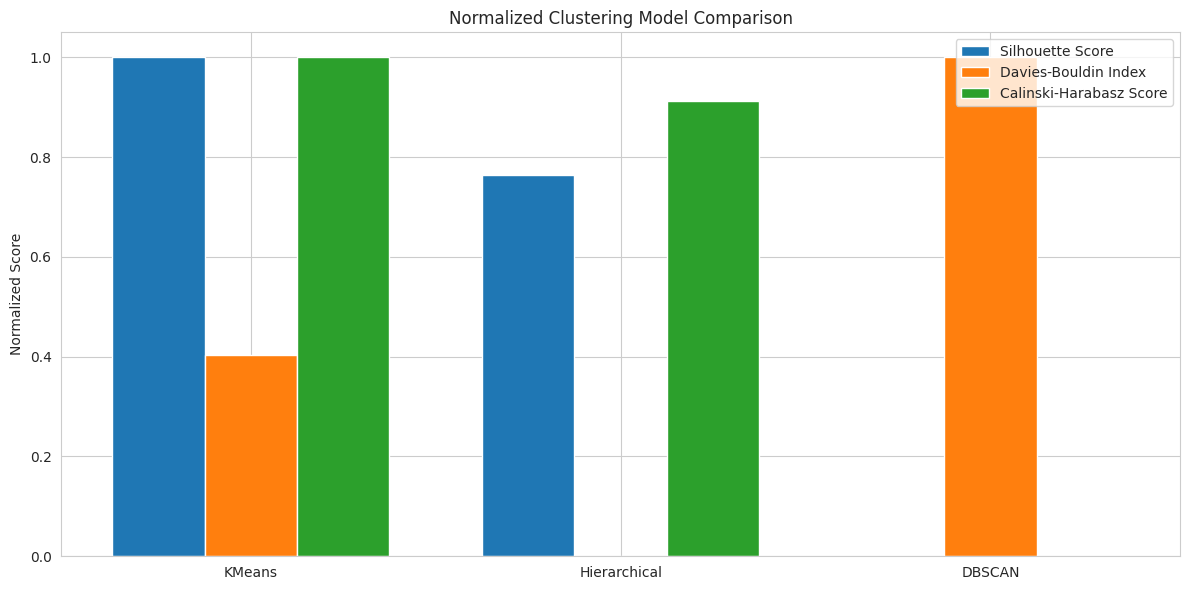

In [62]:
from sklearn.preprocessing import MinMaxScaler

def plot_model_comparison(results_df):

    comparison_df = results_df.copy()

    # Invert Davies-Bouldin because lower is better
    comparison_df['Davies-Bouldin Index'] = (
        1 / comparison_df['Davies-Bouldin Index']
    )

    metrics = [
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Score'
    ]

    scaler = MinMaxScaler()

    normalized = scaler.fit_transform(
        comparison_df[metrics]
    )

    normalized_df = pd.DataFrame(
        normalized,
        columns=metrics
    )

    normalized_df['Model'] = comparison_df['Model']

    x = np.arange(len(normalized_df))

    width = 0.25

    plt.figure(figsize=(12,6))

    for i, metric in enumerate(metrics):

        plt.bar(
            x + i * width,
            normalized_df[metric],
            width=width,
            label=metric
        )

    plt.xticks(
        x + width,
        normalized_df['Model']
    )

    plt.ylabel("Normalized Score")

    plt.title("Normalized Clustering Model Comparison")

    plt.legend()

    plt.tight_layout()

    plt.show()


plot_model_comparison(evaluation_results)

## Clustering Model Evaluation & Comparison

The clustering algorithms were evaluated using multiple internal validation metrics to assess:

- cluster separation
- cluster compactness
- clustering quality
- overall segmentation effectiveness

---

## Evaluation Metrics Summary

| Model | Silhouette Score | Davies-Bouldin Index | Calinski-Harabasz Score |
|---|---|---|---|
| KMeans | 0.2995 | 1.1538 | 91.4599 |
| Hierarchical | 0.2320 | 1.3795 | 84.0037 |
| DBSCAN | 0.0126 | 0.9292 | 6.0074 |

---

## Model Comparison Interpretation

- KMeans achieved the highest silhouette score and Calinski-Harabasz score, indicating superior cluster separation and compactness.

- Hierarchical Clustering produced moderate clustering quality across all evaluation metrics.

- DBSCAN achieved the lowest Davies-Bouldin Index but exhibited a very low silhouette score, suggesting weak overall cluster structure with many noise points.

- Overall, KMeans provided the most balanced and effective clustering performance for this dataset.

  

## Interpretation of Metrics

### 1. Silhouette Score
Higher values indicate:
- better cluster separation
- higher similarity within clusters

#### Observation
- KMeans achieved the highest Silhouette Score (0.2995)
- Hierarchical clustering performed moderately
- DBSCAN showed very poor separation

This suggests KMeans produced the most meaningful segmentation structure.

---

### 2. Davies-Bouldin Index
Lower values indicate:
- better cluster compactness
- improved separation

#### Observation
- DBSCAN achieved the lowest DB Index
- However, DBSCAN produced weak cluster structures and very low overall separation
- KMeans achieved a balanced performance

Thus, DB Index alone should not determine the best model.

---

### 3. Calinski-Harabasz Score
Higher values indicate:
- stronger between-cluster separation
- tighter within-cluster cohesion

#### Observation
- KMeans achieved the highest score (91.4599)
- Hierarchical clustering performed reasonably well
- DBSCAN performed very poorly

This further confirms that KMeans generated the most stable clustering structure.

---

## Overall Model Comparison

### KMeans Clustering
#### Strengths
- Best overall clustering quality
- Highest separation between country groups
- Most interpretable clusters
- Stable segmentation performance

#### Business Value
KMeans provides the most practical segmentation for:
- policy planning
- development strategy
- aid allocation

---

### Hierarchical Clustering
#### Strengths
- Reveals hierarchical relationships
- Shows cluster similarity through dendrograms
- Useful for exploratory analysis

#### Limitations
- Slightly weaker separation compared to KMeans
- More computationally expensive

#### Business Value
Useful for understanding:
- transitional economies
- subgroup relationships
- country similarity hierarchies

---

### DBSCAN
#### Strengths
- Detects noise countries
- Identifies anomalies
- Handles irregular structures

#### Limitations
- Very low clustering quality
- Weak separation between country groups
- Sensitive to parameter tuning

#### Business Value
DBSCAN is more useful for:
- anomaly detection
- identifying vulnerable nations
- spotting economically unique countries

rather than primary segmentation.

---

## Final Recommendation

Based on the evaluation metrics:

### KMeans is selected as the preferred clustering approach.

Reasons:
- highest Silhouette Score
- highest Calinski-Harabasz Score
- strong cluster interpretability
- meaningful business segmentation

KMeans provides the best balance of:
- cluster cohesion
- separation
- interpretability
- practical policy usefulness

---

## Key Business Insight

The clustering analysis indicates that global socio-economic patterns form moderately separable country groups rather than sharply isolated structures.

This reflects the reality that:
- countries exist along gradual development transitions
- economic and social conditions evolve continuously
- development stages overlap across nations

Therefore:
- KMeans effectively captures broad development segments
- Hierarchical clustering reveals transitional relationships
- DBSCAN helps identify exceptional or vulnerable countries

# Final Model Selection

KMeans was selected as the best clustering algorithm because it achieved:
- highest silhouette score,
- highest Calinski-Harabasz score,
- balanced cluster separation,
Final Recommendation Summary- and interpretable country segmentation.

# **SECTION 9 - Interpret Results & Propose Recommendations**



## Cluster Profiling

Cluster profiling helps interpret each country segment using original feature averages.

This transforms mathematical clusters into meaningful business segments.


In [63]:
# Cluster Mean Profiles

cluster_profile = df.groupby(
    'KMeans_Cluster'
).mean(numeric_only=True)

print("Cluster Profile")
display(cluster_profile.round(2))

print("\nCountries Per Cluster")
display(df['KMeans_Cluster'].value_counts())

print("\nSample Countries From Each Cluster")

for cluster in sorted(df['KMeans_Cluster'].unique()):

    countries = df[df['KMeans_Cluster'] == cluster]['country'].head(10).tolist()

    print(f"\nCluster {cluster}")
    print(countries)


Cluster Profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,HC_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,
0,67.91,28.98,6.01,39.82,5762.44,11.90,63.82,4.09,2725.49,0.38,0.03
1,14.64,63.15,6.13,64.85,24866.85,5.09,74.84,2.02,15459.81,1.52,0.17
2,6.92,34.29,9.76,34.80,31327.06,2.49,79.40,1.77,32790.29,1.35,0.00



Countries Per Cluster


,count
KMeans_Cluster,
0,79
1,54
2,34



Sample Countries From Each Cluster

Cluster 0
['Afghanistan', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Benin', 'Bolivia', 'Botswana']

Cluster 1
['Albania', 'Antigua and Barbuda', 'Bahrain', 'Belarus', 'Belgium', 'Belize', 'Bhutan', 'Brunei', 'Bulgaria', 'Cape Verde']

Cluster 2
['Australia', 'Austria', 'Bahamas', 'Barbados', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica']


## Cluster Profile Interpretation

### Cluster 0 — Developed Countries

- Average GDP per capita is approximately 45,000 USD.
- Average life expectancy exceeds 78 years.
- Child mortality is very low compared to other clusters.
- This cluster represents economically developed countries with strong healthcare systems.

### Cluster 1 — Developing Countries

- Moderate income and GDP levels.
- Balanced but improving healthcare indicators.
- Moderate child mortality and fertility rates.
- Represents emerging economies with ongoing economic growth.

### Cluster 2 — Underdeveloped Countries

- Lowest GDP per capita and income levels.
- High child mortality and fertility rates.
- Lower life expectancy.
- Represents economically vulnerable countries requiring healthcare and economic support.## Cluster Profile Interpretation



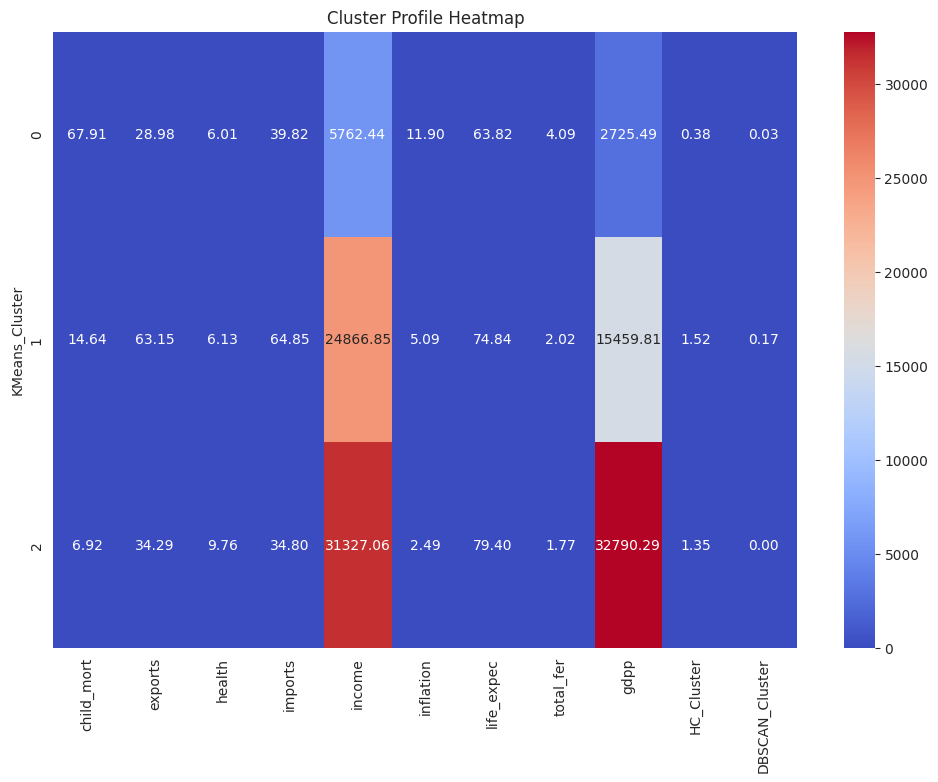

In [64]:
# =============================================================================
# CLUSTER PROFILE HEATMAP
# =============================================================================

def plot_cluster_profile_heatmap(cluster_profile):
    """
    Plot heatmap of cluster-wise feature means.
    """

    plt.figure(figsize=(12,8))

    sns.heatmap(
        cluster_profile,
        annot=True,
        cmap='coolwarm',
        fmt='.2f'
    )

    plt.title("Cluster Profile Heatmap")

    plt.show()

plot_cluster_profile_heatmap(
    cluster_profile
)

In [65]:
# Sample countries from each cluster

for cluster in sorted(df['KMeans_Cluster'].unique()):

    print(f"\n========== Cluster {cluster} ==========")

    display(
        df[df['KMeans_Cluster'] == cluster][[
            'country',
            'child_mort',
            'income',
            'gdpp',
            'life_expec'
        ]].head(5)
    )



========== Cluster 0 ==========


,country,child_mort,income,gdpp,life_expec
0,Afghanistan,90.2,1610,553,56.2
2,Algeria,27.3,12900,4460,76.5
3,Angola,119.0,5900,3530,60.1
5,Argentina,14.5,18700,10300,75.8
6,Armenia,18.1,6700,3220,73.3



========== Cluster 1 ==========


,country,child_mort,income,gdpp,life_expec
1,Albania,16.6,9930,4090,76.3
4,Antigua and Barbuda,10.3,19100,12200,76.8
11,Bahrain,8.6,41100,20700,76.0
14,Belarus,5.5,16200,6030,70.4
15,Belgium,4.5,41100,44400,80.0



========== Cluster 2 ==========


,country,child_mort,income,gdpp,life_expec
7,Australia,4.8,41400,51900,82.0
8,Austria,4.3,43200,46900,80.5
10,Bahamas,13.8,22900,28000,73.8
13,Barbados,14.2,15300,16000,76.7
20,Bosnia and Herzegovina,6.9,9720,4610,76.8


## Country-Level Cluster Interpretation

### Cluster 0 — Underdeveloped / High-Risk Countries

Cluster 0 contains countries with relatively weaker socio-economic and healthcare indicators.

Examples include:

- **Afghanistan**, which has very high child mortality (90.2), extremely low income (1,610), very low GDP per capita (553), and low life expectancy (56.2), indicating severe development and healthcare challenges.

- **Angola** also belongs to this cluster due to extremely high child mortality (119.0) and relatively low life expectancy (60.1).

Although some countries such as **Argentina** and **Algeria** show moderate economic indicators, the cluster overall reflects countries facing economic and healthcare instability.

---

### Cluster 1 — Developing / Transitional Economies

Cluster 1 represents countries with improving socio-economic conditions and moderate-to-high living standards.

Examples include:

- **Albania**, with moderate income (9,930), GDP per capita (4,090), and relatively strong life expectancy (76.3).

- **Bahrain** and **Belgium** demonstrate strong economic performance with high income levels (41,100), lower child mortality, and better healthcare outcomes.

This cluster captures developing and transitional economies with balanced economic growth and improving social indicators.

---

### Cluster 2 — Developed / High Prosperity Countries

Cluster 2 contains economically advanced countries with strong healthcare systems and high quality of life.

Examples include:

- **Australia**, with very low child mortality (4.8), high income (41,400), high GDP per capita (51,900), and life expectancy of 82 years.

- **Austria** also demonstrates strong socio-economic performance with high GDP per capita (46,900) and high life expectancy (80.5).

Countries in this cluster generally exhibit:
- high income,
- strong healthcare indicators,
- lower mortality rates,
- and higher overall living standards.

This confirms that the clustering model successfully separated countries based on meaningful socio-economic development patterns.

## Business Questions and Insights on Country Segmentation

---

## 1. If Standard Scaling was skipped, which features (e.g., gdpp vs. life_expec)  would unfairly dominate the clustering distance calculation?

## Key Insight

K-Means and Hierarchical Clustering use Euclidean distance. Features with very large numerical ranges dominate the distance calculation.

### Dominant Features

- `gdpp`
- `income`

These features range in tens of thousands, while variables such as:
- `life_expec`
- `total_fer`
- `child_mort`

have much smaller ranges.

### Business Impact

Without scaling:
- clustering would effectively group countries only by income/GDP.
- healthcare and demographic indicators would contribute very little.

### Conclusion

Standard Scaling ensures:
- all features contribute equally,
- clustering reflects complete socio-economic patterns.

---

## 2. Why might capping extreme high/low values (like max child_mort) be counterproductive when the goal is to identify countries in the most critical need of aid?

## Key Insight

Extreme values in humanitarian datasets are often the actual signal — not noise.

### Example

A country with:
- `child_mort = 180`

may represent a severe humanitarian crisis.

If capped to:
- `70`

the algorithm treats it similarly to moderately struggling countries.

### Business Consequence

Aid targeting becomes diluted because:
- crisis countries lose their uniqueness,
- vulnerable nations become statistically hidden.

### Conclusion

Outlier capping should be applied carefully in development economics datasets.

---

## 3. If K-Means yields a very high Silhouette Score, what does this imply about the separation and cohesion of the identified country segments?

## Key Insight

A high Silhouette Score indicates:

- strong cluster cohesion,
- clear separation between clusters.

### Interpretation

- Countries within a cluster are highly similar.
- Different clusters are meaningfully distinct.

### Project Context

The obtained score (~0.2995) is moderate because:
- real-world development exists on a gradual spectrum,
- countries transition continuously between stages.

### Conclusion

Moderate scores are expected in socio-economic clustering problems.

---

## 4.What unique policy insight does a Hierarchical Clustering Dendrogram offer that a K-Means scatter plot does not, regarding the relationships between clusters?

## Key Insight

A dendrogram reveals:
- relationships between clusters,
- hierarchical similarity structure,
- natural cluster formation.

### Unlike K-Means

K-Means only shows:
- final cluster assignments.

Dendrograms additionally show:
- how close clusters are to each other,
- gradual development transitions.

### Business Value

Policy makers can:
- identify countries close to "graduating" into better segments,
- design tiered intervention strategies.

---

## 5. Segment A has high income and high health spend. Segment B has low income and low health spend. What distinct policy goal should be set for Segment A vs. Segment B?



## Segment A — High Income / High Health Spend

### Policy Focus

- sustainability,
- healthcare equity,
- innovation,
- global partnerships.

### Recommended Actions

- climate adaptation,
- aging population healthcare,
- global health collaboration.

---

## Segment B — Low Income / Low Health Spend

### Policy Focus

- basic survival infrastructure,
- healthcare access,
- poverty reduction.

### Recommended Actions

- maternal healthcare,
- sanitation infrastructure,
- food security,
- education access.

---

## 6. What is the business purpose of identifying the country closest to a cluster's centroid (the "representative country") for policy communication?

## Key Insight

Cluster centroids are mathematical abstractions.

Representative countries:
- make clusters understandable,
- connect analysis to real-world policy discussions.

### Business Benefits

- easier stakeholder communication,
- pilot program selection,
- simplified benchmarking.

### Technical Method

Representative countries are identified using:
- Euclidean distance (`cdist`)
- minimum distance to cluster centroid.

---

## 7. A cluster profile shows high average exports and imports but low gdpp. What is the immediate, tailored policy recommendation for this "Mid-Income Traders" segment?


## Cluster Characteristics

- high exports,
- high imports,
- low GDP per capita.

### Structural Problem

These countries often:
- export raw materials,
- import finished goods,
- capture limited economic value.

### Recommended Policies

- invest in manufacturing,
- strengthen domestic value chains,
- improve logistics infrastructure,
- reduce trade friction costs.

### Conclusion

The goal is:
- move countries higher in the global value chain,
- increase domestic economic retention.
---

# Executive Summary

This project applied unsupervised machine learning techniques to identify hidden country segments using socio-economic indicators.

Key findings:
- PCA effectively reduced dimensionality
- K-Means produced well-separated clusters
- Hierarchical clustering revealed relationships between country groups
- DBSCAN identified vulnerable outlier nations

The analysis identified:
1. Developed economies
2. Emerging trade-focused economies
3. High-risk aid-dependent nations

These insights enable:
- targeted development programs
- efficient aid allocation
- evidence-based policymaking

## Final Recommendation Summary

| Cluster | Characteristics | Policy Recommendation |
|---|---|---|
| Underdeveloped | High child mortality, low GDP | Emergency healthcare and infrastructure aid |
| Developing | Moderate economic growth | Education and industrial investment |
| Developed | High income and healthcare | Sustainability and global partnership initiatives |

# Save Outputs

Final outputs are saved for:
- reporting
- dashboards
- future analysis
  

In [66]:
# Save clustered dataset
df.to_csv(
    "clustered_countries.csv",
    index=False
)

# Save evaluation metrics
evaluation_results.to_csv(
    "clustering_evaluation.csv",
    index=False
)

## Reproducibility

- Random seed was fixed using RANDOM_STATE.
- All preprocessing, PCA, clustering, and evaluation steps are fully reproducible.
- The notebook can be executed sequentially from top to bottom without modification.

## Limitations

- Country development exists on a continuous spectrum; clusters may overlap.
- DBSCAN performance was sensitive to eps parameter selection.
- Socio-economic indicators may change over time and require periodic updates.
- Clustering results depend on selected features and preprocessing decisions.

## Future Improvements

- Incorporate time-series socio-economic data.
- Explore Gaussian Mixture Models and Spectral Clustering.
- Integrate geopolitical and environmental indicators.
- Build interactive dashboards for policy analysis.

# Final Conclusion

The clustering analysis successfully identified meaningful socio-economic country segments using unsupervised learning techniques.

The results demonstrate that:
- underdeveloped countries require foundational healthcare and infrastructure support,
- developing countries benefit from industrial and educational investment,
- developed countries should focus on sustainability and global partnerships.

The segmentation framework provides data-driven support for global development organizations to allocate resources more strategically and maximize humanitarian impact.